# Define Utils

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import platform
import time
import random
import itertools
import copy
import matplotlib.pyplot as plt

# ---------------------------
# --- Utility Functions ---
# ---------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device(skip_apple_silicon=True):
    if torch.cuda.is_available():
        device = "cuda"
        device_name = f"CUDA GPU ({torch.cuda.get_device_name(0)})"
    elif platform.processor() == 'arm' and platform.system() == 'Darwin' and not skip_apple_silicon:
        if torch.backends.mps.is_available() and torch.backends.mps.is_built():
            device = "mps"
            device_name = "Apple Silicon (MPS)"
        else:
            device = "cpu"
            device_name = "CPU (MPS not available/functional)"
    else:
        device = "cpu"
        device_name = "CPU"
    return torch.device(device), device_name





# Define MLP and SAE functions

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import platform
import time
import random

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def get_device(skip_apple_silicon=True):
    if torch.cuda.is_available():
        device = "cuda"
        device_name = f"CUDA GPU ({torch.cuda.get_device_name(0)})"
    elif platform.processor() == 'arm' and platform.system() == 'Darwin' and not skip_apple_silicon:
        if torch.backends.mps.is_available() and torch.backends.mps.is_built():
            device = "mps"
            device_name = "Apple Silicon (MPS)"
        else:
            device = "cpu"
            device_name = "CPU (MPS not available/functional)"
    else:
        device = "cpu"
        device_name = "CPU"
    return torch.device(device), device_name

class MultiLayerMLP(nn.Module):
    """
    A configurable Multi-Layer Perceptron using a list for hidden layer sizes.
    """
    def __init__(self, input_size, hidden_layers, num_classes):
        super(MultiLayerMLP, self).__init__()
        self.flatten = nn.Flatten()
        layers = []
        last_size = input_size
        for size in hidden_layers:
            layers.append(nn.Linear(last_size, size))
            layers.append(nn.ReLU())
            last_size = size
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(last_size, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        hidden = self.hidden_layers(x)
        output = self.output_layer(hidden)
        return output

    def get_hidden_activations(self, x, extract_layers=None):
        """
        Extracts activations from specified hidden layers.
        If extract_layers is None, returns activations from all hidden layers,
        plus the final hidden layer as 'mlp_activations_tensor'.
        """
        x = self.flatten(x)
        activations = {}
        current = x
        block_idx = 0
        # If no specific layers provided, extract all hidden layers.
        if extract_layers is None:
            extract_layers = list(range(sum(1 for m in self.hidden_layers if isinstance(m, nn.ReLU))))
        for module in self.hidden_layers:
            current = module(current)
            if isinstance(module, nn.ReLU):
                key = f"mlp_hidden_layer_{block_idx+1}_activations"
                activations[key] = current
                block_idx += 1
        activations["mlp_activations_tensor"] = current
        # Filter if a subset is requested.
        if extract_layers is not None:
            filtered = {}
            for idx in extract_layers:
                key = f"mlp_hidden_layer_{idx+1}_activations"
                if key in activations:
                    filtered[key] = activations[key]
            filtered["mlp_activations_tensor"] = current
            return filtered
        return activations

def train_mlp_epoch(model, dataloader, criterion, optimizer, device, epoch, num_epochs):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if (batch_idx + 1) % 300 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{batch_idx+1}/{len(dataloader)}], Loss: {loss.item():.4f}')
    avg_train_loss = running_loss / len(dataloader)
    print(f'Epoch {epoch+1} Average Training Loss: {avg_train_loss:.4f}')
    return avg_train_loss

def test_mlp_epoch(model, dataloader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    avg_loss = test_loss / len(dataloader)
    accuracy = 100. * correct / total
    print(f'Test Set: Average Loss: {avg_loss:.4f}, Accuracy: {correct}/{total} ({accuracy:.2f}%)')
    return avg_loss, accuracy

def extract_mlp_hidden_activations(model, dataloader, device, extract_layers=None):
    model.eval()
    collected_activations = {}
    print("\n--- Extracting MLP Hidden Activations ---")
    start_time = time.time()
    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            batch_acts = model.get_hidden_activations(data, extract_layers=extract_layers)
            for key, acts in batch_acts.items():
                if key not in collected_activations:
                    collected_activations[key] = []
                collected_activations[key].append(acts.cpu())
    end_time = time.time()
    print(f"Extraction Time: {end_time - start_time:.2f} seconds")
    for key in collected_activations:
        collected_activations[key] = torch.cat(collected_activations[key], dim=0)
        print(f"Extracted activation tensor shape ({key}): {collected_activations[key].shape}")
    return collected_activations

def train_MLP(config):
    # Set seed and device
    set_seed(config['seed'])
    DEVICE, DEVICE_NAME = get_device(skip_apple_silicon=config['skip_apple_silicon'])
    print(f"Using device: {DEVICE_NAME} ({DEVICE})")
    
    # Data Loading & Preprocessing for training (normalized)
    print("\n--- Loading MNIST Data (Normalized) ---")
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(config['mnist_mean'], config['mnist_std'])
    ])
    train_dataset_full = torchvision.datasets.MNIST(
        root=config['data_dir'], train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.MNIST(
        root=config['data_dir'], train=False, download=True, transform=transform
    )
    train_loader = DataLoader(train_dataset_full, batch_size=config['batch_size'], shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False, num_workers=0)
    activation_loader = DataLoader(train_dataset_full, batch_size=config['batch_size'], shuffle=False, num_workers=0)
    
    print(f"MNIST training samples: {len(train_dataset_full)}")
    print(f"MNIST test samples: {len(test_dataset)}")
    print("--------------------\n")
    
    # Load unnormalized dataset for visualization
    print("\n--- Loading MNIST Data (Unnormalized for Visualization) ---")
    vis_transform = transforms.Compose([transforms.ToTensor()])  # Only ToTensor() to avoid normalization
    train_dataset_unnormalized = torchvision.datasets.MNIST(
        root=config['data_dir'], train=True, download=True, transform=vis_transform
    )
    vis_loader = DataLoader(train_dataset_unnormalized, batch_size=1024, shuffle=False, num_workers=0)
    original_images_tensor = torch.cat([batch[0] for batch in vis_loader], dim=0).cpu()
    print(f"Original images tensor shape: {original_images_tensor.shape}")
    
    # Initialize model, loss, optimizer
    print("--- Initializing MLP ---")
    model = MultiLayerMLP(config['input_size'], config['hidden_layers'], config['num_classes']).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    print("\n--- MLP Model Architecture ---")
    print(model)
    print("-----------------------------\n")
    
    # Training Loop
    print("--- Starting MLP Training ---")
    start_time = time.time()
    best_accuracy = 0.0
    for epoch in range(config['num_epochs']):
        train_mlp_epoch(model, train_loader, criterion, optimizer, DEVICE, epoch, config['num_epochs'])
        _, accuracy = test_mlp_epoch(model, test_loader, criterion, DEVICE)
        best_accuracy = max(accuracy, best_accuracy)
    end_time = time.time()
    training_time = end_time - start_time
    print("--- MLP Training Finished ---")
    print(f"Final Test Accuracy: {accuracy:.2f}%")
    print(f"Training Time: {training_time:.2f} seconds")
    
    # Activation Extraction (store all hidden layer activations)
    activations_dict = extract_mlp_hidden_activations(model, activation_loader, DEVICE, extract_layers=None)
    mlp_activations_tensor = activations_dict["mlp_activations_tensor"]
    
    # Compile outputs into MLP_out
    MLP_out = {
        "trained_mlp_model": model,
        "mlp_activations_tensor": mlp_activations_tensor,
        "activations_dict": activations_dict,
        "DEVICE": DEVICE,
        "DEVICE_NAME": DEVICE_NAME,
        "training_time": training_time,
        "best_accuracy": best_accuracy,
        "train_dataset_for_indexing": train_dataset_unnormalized,  # for visualization
        "original_images_tensor": original_images_tensor          # unnormalized images
    }
    
    return MLP_out




# RUN Train MLP

In [51]:



# --- Configuration File ---
MLP_CONFIG = {
    # Model and Training Config
    'input_size': 28 * 28,
    'hidden_layers': [64, 32, 16],  # 3 hidden layers with 8 neurons each
    'num_classes': 10,
    'learning_rate': 0.001,
    'batch_size': 64,
    'num_epochs': 10,
    
    # Data Config
    'data_dir': './data',
    'mnist_mean': (0.1307,),
    'mnist_std': (0.3081,),
    
    # Extraction Config: Set to None to extract only the final hidden activation.
    # Otherwise, provide a list of hidden layer indices (0-indexed) to extract.
    'extract_layers': None,  # e.g. [2] or [0,2]
    
    # Other Settings
    'seed': 42,
    'skip_apple_silicon': True
}


# Use your own MLP_CONFIG (do not overwrite your existing one)
MLP_out = train_MLP(MLP_CONFIG)
# Now MLP_out contains the trained model, the final activation tensor,
# and a dictionary with activations from every hidden layer.


Using device: CPU (cpu)

--- Loading MNIST Data (Normalized) ---
MNIST training samples: 60000
MNIST test samples: 10000
--------------------


--- Loading MNIST Data (Unnormalized for Visualization) ---
Original images tensor shape: torch.Size([60000, 1, 28, 28])
--- Initializing MLP ---

--- MLP Model Architecture ---
MultiLayerMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden_layers): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
)
-----------------------------

--- Starting MLP Training ---
Epoch [1/10], Step [300/938], Loss: 0.5904
Epoch [1/10], Step [600/938], Loss: 0.2474
Epoch [1/10], Step [900/938], Loss: 0.1714
Epoch 1 Average Training Loss: 0.4189
Test Set: Average Loss: 0.2103, Accuracy: 9387/10000 (

# Define NTK functions

In [51]:


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time

# --- Helper Functions ---
def compute_jacobian(model: nn.Module, inputs: torch.Tensor, num_classes: int, device: torch.device) -> torch.Tensor:
    model.eval()
    model.to(device)
    inputs = inputs.to(device)
    batch_size = inputs.size(0)
    parameters = [p for p in model.parameters() if p.requires_grad]
    n_params = sum(p.numel() for p in parameters)
    if n_params == 0:
        return None
    jacobian = torch.zeros(batch_size, num_classes, n_params, device=device)
    for i in range(batch_size):
        sample = inputs[i:i+1]
        model.zero_grad()
        outputs = model(sample)
        for c in range(num_classes):
            outputs[0, c].backward(retain_graph=(c < num_classes - 1))
            idx = 0
            for param in parameters:
                if param.grad is not None:
                    jacobian[i, c, idx: idx+param.grad.numel()] = param.grad.flatten()
                    param.grad.zero_()
                idx += param.numel()
    return jacobian

def assemble_kernel(jacobian: torch.Tensor) -> torch.Tensor:
    # Standard NTK: K[i,j] = sum_c J[i,c,p] * J[j,c,p]
    kernel_matrix = torch.einsum('ikp,jkp->ij', jacobian, jacobian)
    return kernel_matrix.detach()

def normalize_kernel(kernel_matrix: torch.Tensor, method: str = 'cosine', epsilon: float = 1e-12) -> torch.Tensor:
    if kernel_matrix is None:
        return None
    if method == 'cosine':
        diag = torch.diag(kernel_matrix)
        diag_sqrt_inv = 1.0 / torch.sqrt(torch.clamp(diag, min=epsilon))
        norm_matrix = torch.outer(diag_sqrt_inv, diag_sqrt_inv)
        normalized_k = kernel_matrix * norm_matrix
        normalized_k = torch.clamp(normalized_k, min=-1.0, max=1.0)
        return normalized_k
    return kernel_matrix

def run_kernel_computation(model: nn.Module, config: dict, device: torch.device, inputs: torch.Tensor) -> torch.Tensor:
    num_classes = config.get('num_classes')
    jacobian = compute_jacobian(model, inputs, num_classes, device)
    kernel_matrix = assemble_kernel(jacobian)
    return kernel_matrix

# --- NTK Wrapper Function ---
def run_ntk_from_config(ntk_config: dict) -> dict:
    """
    Computes the standard NTK for the given MLP model.
    
    ntk_config must include:
      - 'trained_model': the trained MLP model (from MLP_out['trained_mlp_model'])
      - 'train_dataset_full': the full training dataset (torchvision.datasets.MNIST)
      - 'MLP_out': the full MLP output dictionary (with key "train_dataset_for_indexing")
      - 'MLP_CONFIG': configuration dictionary (must include 'num_classes')
      - 'DEVICE': torch.device
      - 'N_SAMPLES_PER_LABEL': number of samples per label to select
      - 'LABELS_TO_SELECT': list of integer labels to select (ordered as desired)
    
    Returns a dictionary containing:
      - 'kernel_standard' and its normalized version,
      - the input batch and targets,
      - and the selected sample indices.
    """
    trained_model = ntk_config['trained_model']
    # Use the training dataset from MLP_out
    train_dataset = ntk_config['MLP_out'].get("train_dataset_for_indexing")
    if train_dataset is None:
        data_dir = ntk_config.get('data_dir', './data')
        train_dataset = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=transforms.ToTensor())
    MLP_CONFIG = ntk_config['MLP_CONFIG']
    DEVICE = ntk_config['DEVICE']
    N_SAMPLES_PER_LABEL = ntk_config.get('N_SAMPLES_PER_LABEL', 5)
    LABELS_TO_SELECT = sorted(ntk_config.get('LABELS_TO_SELECT', list(range(10))))
    
    final_indices = []
    dataset_targets = train_dataset.targets
    for label in LABELS_TO_SELECT:
        count = 0
        for idx, target in enumerate(dataset_targets):
            current = target.item() if isinstance(target, torch.Tensor) else target
            if current == label:
                final_indices.append(idx)
                count += 1
                if count >= N_SAMPLES_PER_LABEL:
                    break

    subset = Subset(train_dataset, final_indices)
    loader = DataLoader(subset, batch_size=len(final_indices), shuffle=False)
    inputs, targets = next(iter(loader))
    
    kernel_standard = run_kernel_computation(model=trained_model, config=MLP_CONFIG, device=DEVICE, inputs=inputs)
    kernel_standard_norm = normalize_kernel(kernel_standard, method='cosine')
    
    return {
        "kernel_standard": kernel_standard,
        "kernel_standard_norm": kernel_standard_norm,
        "inputs": inputs,
        "targets": targets,
        "selected_indices": final_indices
    }


# RUN NTK

In [51]:

# --- Example Usage ---
if __name__ == "__main__":
    # Assume MLP_out is produced by your training code and contains:
    # 'trained_mlp_model', 'train_dataset_for_indexing', 'DEVICE', and 'MLP_CONFIG'
    trained_model = MLP_out["trained_mlp_model"]
    ntk_config = {
        "trained_model": trained_model,
        "train_dataset_full": MLP_out["train_dataset_for_indexing"],
        "MLP_out": MLP_out,
        "MLP_CONFIG": MLP_CONFIG,
        "DEVICE": MLP_out["DEVICE"],
        "N_SAMPLES_PER_LABEL": 5,
        "LABELS_TO_SELECT": [0, 7, 5, 1]
    }
    
    ntk_results = run_ntk_from_config(ntk_config)
    
    print("Standard NTK shape:", ntk_results["kernel_standard"].shape)
    print("Normalized Standard NTK shape:", ntk_results["kernel_standard_norm"].shape)


Standard NTK shape: torch.Size([20, 20])
Normalized Standard NTK shape: torch.Size([20, 20])


# PLOT NTK visualization

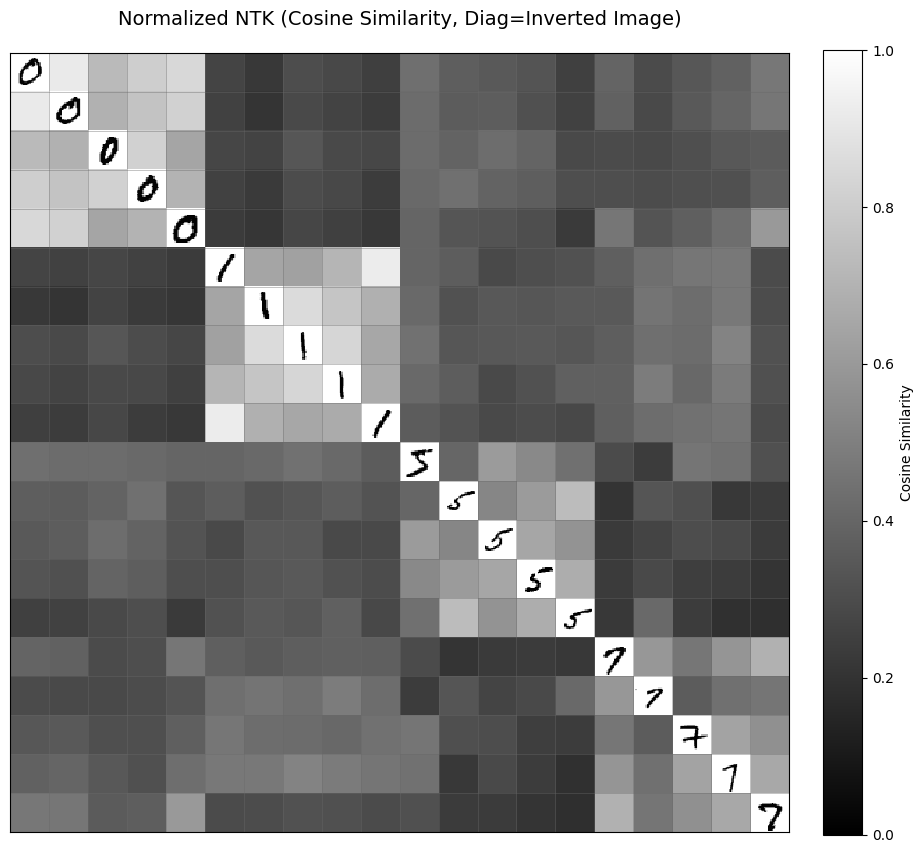

NTK visualization complete.


In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

# --- Helper Function: Plot Upscaled Kernel with Inverted Diagonals ---
def plot_kernel_upscaled_with_images(matrix_data_cpu_np, images_tensor_cpu, title,
                                     figsize=(11, 11), cmap='gray', vmin=None, vmax=None,
                                     cbar_label="Kernel Value", grid_color='dimgray', background_color='white'):
    """
    Plots an upscaled kernel matrix with inverted images on the diagonal.
    The off-diagonal patches show the kernel values and the diagonal shows the inverted images.
    """
    N = matrix_data_cpu_np.shape[0]
    if not isinstance(matrix_data_cpu_np, np.ndarray):
        matrix_data_cpu_np = matrix_data_cpu_np.cpu().numpy()
    images_np = images_tensor_cpu.cpu().numpy() if isinstance(images_tensor_cpu, torch.Tensor) else images_tensor_cpu
    if images_np.shape[0] != N:
        raise ValueError("Number of images must match kernel matrix dimension.")
    # Expected images_np shape: [N, 1, H, W]
    _, _, H, W = images_np.shape
    canvas = np.full((N * H, N * W), np.nan, dtype=np.float32)
    for i in range(N):
        for j in range(N):
            row0, row1 = i * H, (i + 1) * H
            col0, col1 = j * W, (j + 1) * W
            if i == j:
                image_data = images_np[i, 0, :, :]
                canvas[row0:row1, col0:col1] = 1.0 - np.clip(image_data, 0.0, 1.0)
            else:
                canvas[row0:row1, col0:col1] = matrix_data_cpu_np[i, j]
    fig, ax = plt.subplots(figsize=figsize)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color=background_color)
    if vmin is None or vmax is None:
        off_diag = matrix_data_cpu_np[~np.eye(N, dtype=bool)]
        valid = off_diag[~np.isnan(off_diag)]
        vmin = valid.min() if vmin is None else vmin
        vmax = valid.max() if vmax is None else vmax
    if cmap in ['coolwarm', 'seismic', 'RdBu', 'bwr']:
        abs_max = np.nanmax(np.abs([vmin, vmax]))
        vmin, vmax = -abs_max, abs_max
    if np.isclose(vmin, vmax):
        vmin -= 0.1; vmax += 0.1
    im = ax.imshow(canvas, cmap=cmap_obj, vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xticks(np.arange(W - 0.5, N * W, W), minor=True)
    ax.set_yticks(np.arange(H - 0.5, N * H, H), minor=True)
    ax.grid(which='minor', color=grid_color, linestyle='-', linewidth=0.7, alpha=0.4)
    ax.tick_params(which='minor', size=0)
    ax.set_xlim(-0.5, N * W - 0.5)
    ax.set_ylim(N * H - 0.5, -0.5)
    cbar = fig.colorbar(im, ax=ax, label=cbar_label, fraction=0.046, pad=0.04)
    plt.show()

# --- NTK Visualization Wrapper Function ---
def run_ntk_visualization_from_config(ntk_plot_config: dict):
    """
    Runs NTK visualization using the provided configuration dictionary.
    
    ntk_plot_config must include:
      - 'kernel_standard': the computed NTK (from run_ntk_from_config)
      - 'MLP_out': full MLP output dict (must include 'train_dataset_for_indexing', 'original_images_tensor')
      - 'data_dir': (optional) path to data if needed
      - 'figsize': (optional) figure size for upscaled plot
      - 'cmap': (optional) colormap to use (default 'gray')
      - 'vmin': (optional) minimum for color scale
      - 'vmax': (optional) maximum for color scale
      - 'cbar_label': (optional) label for the colorbar
      - 'title': (optional) plot title
    """
    kernel_standard = ntk_plot_config['kernel_standard']
    MLP_out = ntk_plot_config['MLP_out']
    # Get the selected subset of images (these must match the NTK kernel dimension)
    if "selected_indices" in ntk_plot_config:
        selected_indices = ntk_plot_config["selected_indices"]
    else:
        # If not provided, assume MLP_out["train_dataset_for_indexing"] was used.
        # In that case, we use the entire dataset.
        selected_indices = list(range(len(MLP_out["train_dataset_for_indexing"])))
    # Load original images from MLP_out and restrict to selected indices.
    original_images_full = MLP_out.get("original_images_tensor")
    if original_images_full is None:
        data_dir = ntk_plot_config.get('data_dir', './data')
        ds = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=transforms.ToTensor())
        loader = DataLoader(ds, batch_size=1024, shuffle=False)
        original_images_full = torch.cat([batch[0] for batch in loader], dim=0).cpu()
    # Restrict to selected indices.
    original_images = original_images_full[selected_indices]
    
    # Normalize the kernel if not provided.
    if "kernel_standard_norm" in ntk_plot_config and ntk_plot_config["kernel_standard_norm"] is not None:
        kernel_norm = ntk_plot_config["kernel_standard_norm"]
    else:
        diag = torch.diag(kernel_standard)
        diag_sqrt_inv = 1.0 / torch.sqrt(torch.clamp(diag, min=1e-12))
        norm_matrix = torch.outer(diag_sqrt_inv, diag_sqrt_inv)
        kernel_norm = torch.clamp(kernel_standard * norm_matrix, min=-1.0, max=1.0)
    
    kernel_np = kernel_norm.cpu().numpy()
    
    plot_kernel_upscaled_with_images(
        matrix_data_cpu_np=kernel_np,
        images_tensor_cpu=original_images,
        title=ntk_plot_config.get("title", "Normalized NTK (Cosine Similarity, Diag=Inverted Image)"),
        figsize=ntk_plot_config.get("figsize", (11, 11)),
        cmap=ntk_plot_config.get("cmap", "gray"),
        vmin=ntk_plot_config.get("vmin", 0.0),
        vmax=ntk_plot_config.get("vmax", 1.0),
        cbar_label=ntk_plot_config.get("cbar_label", "Cosine Similarity")
    )
    print("NTK visualization complete.")

# --- Example Usage ---
if __name__ == "__main__":
    # Assume that you have computed your NTK via run_ntk_from_config and stored it in kernel_results,
    # and that MLP_out, MLP_CONFIG, and DEVICE are available.
    # For example:
    #    kernel_results = run_ntk_from_config(ntk_config)
    # and that kernel_results contains "kernel_standard" and "selected_indices".
    # Also, ensure that MLP_out contains "train_dataset_for_indexing" and "original_images_tensor".
    kernel_results = ntk_results  # Assume this is defined from previous NTK computation.
    ntk_plot_config = {
        "kernel_standard": kernel_results["kernel_standard"],
        "kernel_standard_norm": kernel_results["kernel_standard_norm"],
        "MLP_out": MLP_out,
        "data_dir": MLP_out.get("data_dir", "./data"),
        "figsize": (11, 11),
        "cmap": "gray",
        "vmin": 0.0,
        "vmax": 1.0,
        "cbar_label": "Cosine Similarity",
        "title": "Normalized NTK (Cosine Similarity, Diag=Inverted Image)",
        "selected_indices": kernel_results["selected_indices"]
    }
    run_ntk_visualization_from_config(ntk_plot_config)


# Define SAE code

In [51]:

# ---------------------------
# --- SAE Model & Training ---
# ---------------------------
class SAE(nn.Module):
    """Sparse Autoencoder with one hidden layer."""
    def __init__(self, input_size, hidden_size):
        super(SAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU()
        )
        self.decoder = nn.Linear(hidden_size, input_size)
    
    def forward(self, x):
        encoded = self.encoder(x)
        reconstructed = self.decoder(encoded)
        return reconstructed, encoded

def train_sae_epoch(model, dataloader, criterion_mse, optimizer, device, epoch, config):
    model.train()
    total_loss = 0.0
    total_mse_loss = 0.0
    total_l1_loss = 0.0
    total_l2_loss = 0.0
    total_l0_norm = 0.0
    total_elements = 0
    l1_coeff = config['l1_coeff']
    l2_coeff = config['l2_coeff']
    for batch_idx, (activations,) in enumerate(dataloader):
        activations = activations.to(device)
        optimizer.zero_grad()
        reconstruction, sae_hidden = model(activations)
        mse_loss = criterion_mse(reconstruction, activations)
        l1_loss = torch.mean(torch.abs(sae_hidden))
        l2_loss = torch.mean(sae_hidden ** 2)
        loss = mse_loss + l1_coeff * l1_loss + l2_coeff * l2_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * activations.size(0)
        total_mse_loss += mse_loss.item() * activations.size(0)
        total_l1_loss += l1_loss.item() * activations.size(0)
        total_l2_loss += l2_loss.item() * activations.size(0)
        l0_norm = torch.sum(sae_hidden > 1e-6).item()
        total_l0_norm += l0_norm
        total_elements += sae_hidden.numel()
    avg_loss = total_loss / len(dataloader.dataset)
    avg_mse = total_mse_loss / len(dataloader.dataset)
    avg_l1 = total_l1_loss / len(dataloader.dataset)
    avg_l2 = total_l2_loss / len(dataloader.dataset)
    avg_l0 = total_l0_norm / total_elements
    print(f'SAE Epoch {epoch+1} Avg Loss -> Total: {avg_loss:.6f}, MSE: {avg_mse:.6f}, '
          f'L1: {avg_l1:.6f}, L2: {avg_l2:.6f}, L0 Sparsity: {avg_l0:.4f}')
    return avg_loss, avg_mse, avg_l1, avg_l2, avg_l0

def analyze_sae(model, activation_data, device):
    print("\n--- SAE Analysis (Reconstruction Check) ---")
    model.eval()
    model.to(device)
    num_samples = 5
    sample_indices = torch.randperm(len(activation_data))[:num_samples]
    samples = activation_data[sample_indices].to(device)
    with torch.no_grad():
        reconstructions, _ = model(samples)
    total_mse = 0
    for i in range(num_samples):
        orig = samples[i].cpu().numpy()
        recon = reconstructions[i].cpu().numpy()
        mse = np.mean((orig - recon) ** 2)
        total_mse += mse
        print(f" Sample {i+1}: MSE = {mse:.6f}")
    print(f" Average MSE over {num_samples} samples: {total_mse / num_samples:.6f}")
    print("--- End Analysis ---")



def train_SAE(SAE_config, MLP_config, MLP_out):
    """
    Trains the SAE using the extracted MLP activations.
    
    Args:
        SAE_config (dict): SAE configuration (includes selected_layer_index, learning rates, etc.).
        MLP_config (dict): MLP configuration (used for seed and hidden layer sizes).
        MLP_out (dict): Output from the MLP pipeline.
    
    Returns:
        SAE_out (dict): Contains the trained SAE model, training metrics (including practical reconstruction MSE),
                        normalized activations, training time, and device.
    """
    set_seed(MLP_config['seed'])
    device = MLP_out["DEVICE"]
    selected_idx = SAE_config['selected_layer_index']
    try:
        sae_input_size = MLP_config['hidden_layers'][selected_idx]
    except IndexError:
        raise ValueError("selected_layer_index is out of range for MLP_config['hidden_layers']")
    
    # If a scaling factor is provided, compute hidden_size accordingly.
    # if "SAE_scale_factor" in SAE_config:
    SAE_config['hidden_size'] = sae_input_size * SAE_config["SAE_scale_factor"]
    SAE_config['input_size'] = sae_input_size

    print(f"\n--- Initializing SAE ---")
    print(f"Using SAE input size: {sae_input_size} (from MLP hidden layer index {selected_idx})")

    if selected_idx == len(MLP_config['hidden_layers']) - 1:
        activation_data = MLP_out["mlp_activations_tensor"]
    else:
        key = f"mlp_hidden_layer_{selected_idx+1}_activations"
        activation_data = MLP_out["activations_dict"].get(key, None)
        if activation_data is None:
            raise ValueError(f"Activation data for hidden layer index {selected_idx} not found in MLP_out.")

    print("Normalizing activation data...")
    activation_mean = activation_data.mean(dim=0, keepdim=True)
    activation_std = activation_data.std(dim=0, keepdim=True) + 1e-8
    normalized_activations = (activation_data - activation_mean) / activation_std

    sae_model = SAE(SAE_config['input_size'], SAE_config['hidden_size']).to(device)
    criterion_mse = nn.MSELoss()
    sae_optimizer = optim.Adam(sae_model.parameters(), lr=SAE_config['learning_rate'])

    print("\n--- SAE Model Architecture ---")
    print(sae_model)
    print(f"Input: {SAE_config['input_size']}, Hidden: {SAE_config['hidden_size']}")
    print(f"LR: {SAE_config['learning_rate']}, L1: {SAE_config['l1_coeff']}, L2: {SAE_config['l2_coeff']}")
    print("----------------------------\n")

    activation_dataset = TensorDataset(normalized_activations)
    sae_loader = DataLoader(activation_dataset, batch_size=SAE_config['batch_size'], shuffle=True)

    # Use 100 samples for the practical reconstruction check.
    recon_sample = normalized_activations[:100].to(device)
    sae_metrics = {'loss': [], 'mse': [], 'l1': [], 'l2': [], 'l0': [], 'reconstruction': []}
    start_time = time.time()
    for epoch in range(SAE_config['num_epochs']):
        avg_loss, avg_mse, avg_l1, avg_l2, avg_l0 = train_sae_epoch(
            sae_model, sae_loader, criterion_mse, sae_optimizer, device, epoch, SAE_config
        )
        with torch.no_grad():
            recon, _ = sae_model(recon_sample)
            # Compute the reconstruction error on these 100 samples.
            recon_mse = torch.mean((recon - recon_sample) ** 2).item()
        sae_metrics['loss'].append(avg_loss)
        sae_metrics['mse'].append(avg_mse)
        sae_metrics['l1'].append(avg_l1)
        sae_metrics['l2'].append(avg_l2)
        sae_metrics['l0'].append(avg_l0)
        sae_metrics['reconstruction'].append(recon_mse)
        print(f"Epoch {epoch+1}: Practical Reconstruction MSE = {recon_mse:.6f}")
    end_time = time.time()
    training_time = end_time - start_time

    print("--- SAE Training Finished ---")
    print(f"SAE Training Time: {training_time:.2f} seconds")
    print(f"Final SAE Avg Loss: {sae_metrics['loss'][-1]:.6f}")

    save_path = f'mnist_sae_trained_l1_{SAE_config["l1_coeff"]}_l2_{SAE_config["l2_coeff"]}.pth'
    torch.save(sae_model.state_dict(), save_path)
    print(f"SAE model saved to {save_path}")

    analyze_sae(sae_model, activation_data, device)

    SAE_out = {
        "trained_sae_model": sae_model,
        "sae_training_metrics": sae_metrics,
        "normalized_activations": normalized_activations,
        "training_time": training_time,
        "DEVICE": device,
        "save_path": save_path
    }
    return SAE_out


# ---------------------------
# --- Grid Search Function ---
# ---------------------------
def grid_search_SAE(GRID_CONFIG):
    """
    Performs grid search over SAE configurations.
    
    GRID_CONFIG (dict) must include:
      - "SAE_CONFIG_grid": dict of SAE parameter lists for grid search.
      - "MLP_CONFIG": your MLP configuration.
      - "MLP_out": output from your MLP pipeline.
      - Optionally, "SAE_CONFIG_base": dict of SAE parameters that remain constant.
    
    Returns:
      GRID_out (dict): Contains list of all grid search results and the best configuration.
    """
    results = []
    base_SAE_config = {}
    if "SAE_CONFIG_base" in GRID_CONFIG:
        base_SAE_config.update(GRID_CONFIG["SAE_CONFIG_base"])
    grid_params = GRID_CONFIG["SAE_CONFIG_grid"]
    keys = list(grid_params.keys())
    combinations = list(itertools.product(*(grid_params[k] for k in keys)))
    best_loss = float('inf')
    best_result = None
    for combo in combinations:
        sae_config = copy.deepcopy(base_SAE_config)
        for k, v in zip(keys, combo):
            sae_config[k] = v
        print("\n==============================")
        print("Testing SAE configuration:", sae_config)
        print("==============================\n")
        SAE_out = train_SAE(sae_config, GRID_CONFIG["MLP_CONFIG"], GRID_CONFIG["MLP_out"])
        final_loss = SAE_out["sae_training_metrics"]['loss'][-1]
        result_entry = {
            "SAE_config": sae_config,
            "SAE_out": SAE_out,
            "final_loss": final_loss
        }
        results.append(result_entry)
        if final_loss < best_loss:
            best_loss = final_loss
            best_result = result_entry
    GRID_out = {
        "all_results": results,
        "best_result": best_result
    }
    return GRID_out



# RUN train SAE

In [51]:




SAE_config =  {
        "selected_layer_index": 1,  # index of MLP layer to use
        "SAE_scale_factor": 4,      # if provided, SAE hidden_size = MLP_CONFIG['hidden_layers'][selected_index]*scale_factor
        "learning_rate": 0.0001,
        "batch_size": 64,
        "num_epochs": 50,
        "l1_coeff": 8,
        "l2_coeff": 0.01,
        # "hidden_size": 128, # do not define this use SAE scale factor
    }
SAE_out = train_SAE(SAE_config, MLP_CONFIG, MLP_out)



--- Initializing SAE ---
Using SAE input size: 32 (from MLP hidden layer index 1)
Normalizing activation data...

--- SAE Model Architecture ---
SAE(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
  )
  (decoder): Linear(in_features=128, out_features=32, bias=True)
)
Input: 32, Hidden: 128
LR: 0.0001, L1: 8, L2: 0.01
----------------------------

SAE Epoch 1 Avg Loss -> Total: 1.682302, MSE: 0.667354, L1: 0.126782, L2: 0.068817, L0 Sparsity: 0.4246
Epoch 1: Practical Reconstruction MSE = 0.532752
SAE Epoch 2 Avg Loss -> Total: 0.911669, MSE: 0.464601, L1: 0.055847, L2: 0.029106, L0 Sparsity: 0.2593
Epoch 2: Practical Reconstruction MSE = 0.378454
SAE Epoch 3 Avg Loss -> Total: 0.660137, MSE: 0.349128, L1: 0.038837, L2: 0.031434, L0 Sparsity: 0.1543
Epoch 3: Practical Reconstruction MSE = 0.297616
SAE Epoch 4 Avg Loss -> Total: 0.543864, MSE: 0.286919, L1: 0.032077, L2: 0.033059, L0 Sparsity: 0.0992
Epoch 4: Practical Reconstructio

# PLOT SAE training

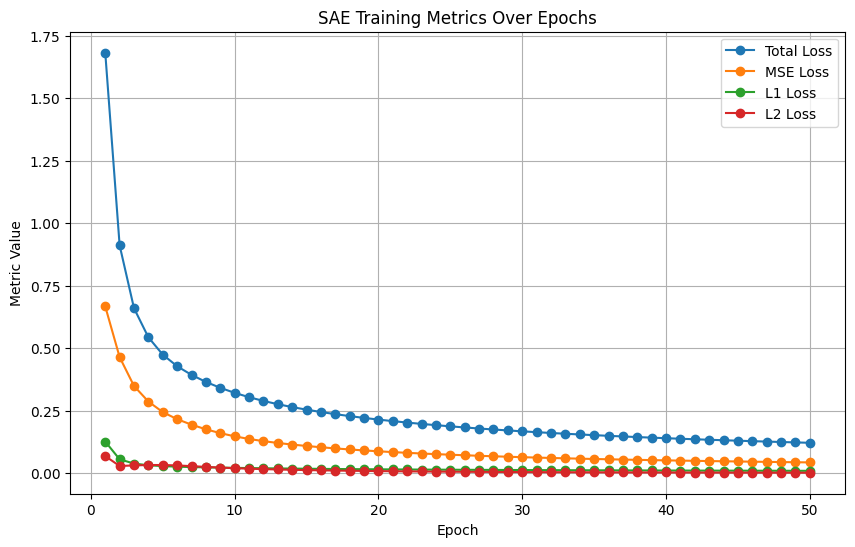

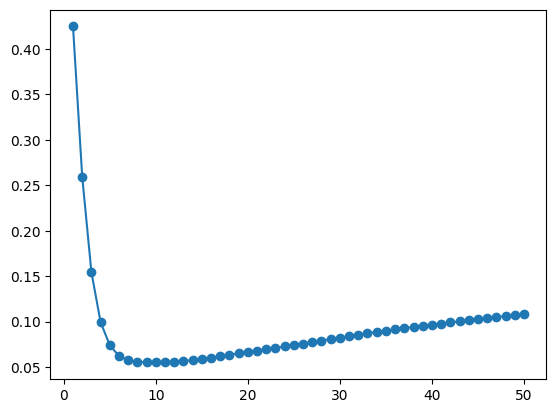

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract metrics from SAE_out.
metrics = SAE_out["sae_training_metrics"]
num_epochs = len(metrics["loss"])
epochs = list(range(1, num_epochs + 1))

# Create a DataFrame (optional but useful for inspection).
df = pd.DataFrame({
    "Epoch": epochs,
    "Total Loss": metrics["loss"],
    "MSE Loss": metrics["mse"],
    "L1 Loss": metrics["l1"],
    "L2 Loss": metrics["l2"],
    "L0 Sparsity": metrics["l0"]
})

# Plot each metric over epochs.
plt.figure(figsize=(10, 6))
plt.plot(df["Epoch"], df["Total Loss"], label="Total Loss", marker="o")
plt.plot(df["Epoch"], df["MSE Loss"], label="MSE Loss", marker="o")
plt.plot(df["Epoch"], df["L1 Loss"], label="L1 Loss", marker="o")
plt.plot(df["Epoch"], df["L2 Loss"], label="L2 Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("SAE Training Metrics Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["Epoch"], df["L0 Sparsity"], label="L0 Sparsity", marker="o")

# Define SAE feature Vis

In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import seaborn as sns
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

# --- Helper Functions ---

@torch.no_grad()
def get_sae_layer_activations(sae_model, activation_data, device, 
                              selected_submodule="encoder", selected_layer_index=None, 
                              batch_size=1024):
    """
    Gets activations from the specified SAE submodule.
    
    Parameters:
        sae_model: The trained SAE.
        activation_data: Input activation tensor from the MLP.
        device: Device to run on.
        selected_submodule: One of "encoder", "decoder", or "full".
        selected_layer_index: (Optional) If provided, use only the output of that intermediate layer.
        batch_size: Batch size for processing.
        
    Returns:
        Concatenated activations tensor.
    """
    sae_model.eval()
    sae_model.to(device)
    activation_data = activation_data.cpu().float()
    temp_dataset = TensorDataset(activation_data)
    temp_loader = DataLoader(temp_dataset, batch_size=batch_size, shuffle=False)
    all_acts = []
    
    for (batch,) in temp_loader:
        batch = batch.to(device)
        if selected_submodule == "encoder":
            acts = sae_model.encoder(batch)
            if selected_layer_index is not None:
                # Assume encoder is Sequential; run layer-by-layer until the selected index.
                for i, module in enumerate(sae_model.encoder):
                    batch = module(batch)
                    if i == selected_layer_index:
                        acts = batch
                        break
        elif selected_submodule == "decoder":
            # Get encoder output first.
            encoded = sae_model.encoder(batch)
            if selected_layer_index is not None:
                # If decoder has multiple layers (usually it's a single Linear)
                for i, module in enumerate(sae_model.decoder):
                    encoded = module(encoded)
                    if i == selected_layer_index:
                        acts = encoded
                        break
            else:
                acts = sae_model.decoder(encoded)
        elif selected_submodule == "full":
            acts = sae_model(batch)
        else:
            raise ValueError("Invalid selected_submodule. Choose from 'encoder', 'decoder', 'full'.")
        all_acts.append(acts.cpu())
    return torch.cat(all_acts, dim=0)

def get_top_activating_examples(feature_activations, top_k=16):
    max_act = torch.max(feature_activations).item()
    if max_act < 1e-6:
        return None, None, max_act
    k = min(top_k, len(feature_activations))
    top_vals, top_indices = torch.topk(feature_activations, k=k)
    return top_indices, top_vals, max_act

def calculate_weighted_average_top_k(top_indices, top_vals, original_images):
    if top_indices is None or top_vals is None:
        return None
    total_weight = torch.sum(top_vals)
    if total_weight.item() < 1e-9:
        return None
    top_imgs = original_images[top_indices].float()
    weights = top_vals.float().view(-1, 1, 1, 1)
    weighted_sum = torch.sum(weights * top_imgs, dim=0)
    avg_img = weighted_sum / total_weight
    return avg_img

def enhance_heatmap(avg_img_tensor, gamma=1.0):
    if avg_img_tensor is None:
        return None, None
    img_min = torch.min(avg_img_tensor)
    img_max = torch.max(avg_img_tensor)
    if img_max - img_min < 1e-8:
        norm_img = torch.zeros_like(avg_img_tensor)
    else:
        norm_img = (avg_img_tensor - img_min) / (img_max - img_min)
    enhanced = norm_img ** gamma
    return enhanced, norm_img

def plot_enhanced_heatmap(ax, enhanced_img, gamma=1.0, title=""):
    if enhanced_img is None:
        ax.text(0.5, 0.5, 'Dead/Inactive', horizontalalignment='center',
                verticalalignment='center', fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
        return None
    img_np = enhanced_img.squeeze().numpy()
    im = ax.imshow(img_np, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    
    def percent_formatter(x, pos):
        return f"{(x**(1/gamma)*100):.0f}%"
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_major_formatter(ticker.FuncFormatter(percent_formatter))
    return im

def plot_mnist_examples(ax_array, images_list, titles_list):
    ax_array = np.array(ax_array).flatten()
    for i, ax in enumerate(ax_array):
        if i < len(images_list):
            img = images_list[i]
            if isinstance(img, torch.Tensor):
                img = img.squeeze().numpy()
            ax.imshow(img, cmap='gray')
            ax.set_title(titles_list[i], fontsize=7)
            ax.axis('off')
        else:
            ax.axis('off')

def create_overlay_image(digit_img, heatmap, do_norm=True, digit_opacity=0.5):
    if isinstance(digit_img, torch.Tensor):
        digit_img = digit_img.squeeze().numpy()
    if isinstance(heatmap, torch.Tensor):
        heatmap = heatmap.squeeze().numpy()
    if do_norm:
        a = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8)
        b = (digit_img - np.min(digit_img)) / (np.max(digit_img) - np.min(digit_img) + 1e-8)
        b = b * digit_opacity
    else:
        a = heatmap
        b = digit_img * digit_opacity
    weight_white = (1 - a) * (1 - b)
    weight_red   = a * (1 - b)
    weight_blue  = (1 - a) * b
    weight_purple= a * b
    white = np.array([1.0, 1.0, 1.0])
    red   = np.array([1.0, 0.0, 0.0])
    blue  = np.array([0.0, 0.0, 1.0])
    purple= np.array([0.5, 0.0, 0.5])
    overlay = (weight_white[..., None] * white +
               weight_red[..., None]   * red +
               weight_blue[..., None]  * blue +
               weight_purple[..., None]* purple)
    return np.clip(overlay, 0, 1)

# --- Main Visualization Function ---

def run_sae_visualization_from_config(plot_config):
    """
    Runs the SAE visualization using the provided configuration dictionary.
    """
    trained_sae_model = plot_config['trained_sae_model']
    MLP_out = plot_config['MLP_out']
    
    # Get the dataset for indexing images.
    if 'train_dataset_for_indexing' in MLP_out:
        train_dataset = MLP_out["train_dataset_for_indexing"]
    else:
        data_dir = plot_config.get('data_dir', './data')
        train_dataset = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=transforms.ToTensor())
    
    # Get the original images.
    if 'original_images_tensor' in MLP_out:
        original_images = MLP_out["original_images_tensor"]
    else:
        data_dir = plot_config.get('data_dir', './data')
        ds = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=transforms.ToTensor())
        loader = DataLoader(ds, batch_size=1024, shuffle=False)
        original_images = torch.cat([batch[0] for batch in loader], dim=0).cpu()
    
    DEVICE = MLP_out["DEVICE"]
    NUM_FEATURES = plot_config.get('NUM_FEATURES_TO_VISUALIZE', 40)
    TOP_K_DISPLAY = plot_config.get('TOP_K_DISPLAY', 16)
    TOP_K_WEIGHTED = plot_config.get('TOP_K_WEIGHTED', 1000)
    GAMMA = plot_config.get('ENHANCEMENT_GAMMA', 4)
    SORT_METRIC = plot_config.get('SORT_METRIC', 'max_activation')
    show_overlay = plot_config.get('show_heatmap_overlay', True)
    overlay_type = plot_config.get('overlay_image_type', 'enhanced')
    overlay_opacity = plot_config.get('overlay_digit_opacity', 0.5)
    
    # MLP activations to feed the SAE (must match SAE training)
    selected_mlp_layer = plot_config.get('selected_layer_index_for_SAE', None)
    if selected_mlp_layer is not None:
        mlp_act_data = MLP_out["activations_dict"].get(f"mlp_hidden_layer_{selected_mlp_layer+1}_activations", None)
        if mlp_act_data is None:
            mlp_act_data = MLP_out["mlp_activations_tensor"]
    else:
        mlp_act_data = MLP_out["mlp_activations_tensor"]
    
    # SAE activations:
    selected_sae_submodule = plot_config.get('selected_sae_submodule', "encoder")  # "encoder", "decoder", or "full"
    selected_sae_layer_index = plot_config.get('selected_sae_layer_index', None)    # Optional layer index within the chosen submodule
    
    if 'all_sae_acts' not in plot_config or plot_config['all_sae_acts'] is None:
        all_sae_acts = get_sae_layer_activations(trained_sae_model, mlp_act_data, DEVICE,
                                                 selected_submodule=selected_sae_submodule,
                                                 selected_layer_index=selected_sae_layer_index)
    else:
        all_sae_acts = plot_config['all_sae_acts']
    
    total_features = all_sae_acts.shape[1]
    if SORT_METRIC == 'max_activation':
        metric = torch.max(all_sae_acts, dim=0).values
        sorted_idx = torch.argsort(metric, descending=True)
        sorted_metric = metric[sorted_idx]
    elif SORT_METRIC == 'median_activation':
        medians = []
        for i in range(total_features):
            acts = all_sae_acts[:, i]
            k = min(TOP_K_WEIGHTED, len(acts))
            top_vals, _ = torch.topk(acts, k=k)
            medians.append(top_vals.median().item())
        metric = torch.tensor(medians)
        sorted_idx = torch.argsort(metric, descending=True)
        sorted_metric = metric[sorted_idx]
    else:
        sorted_idx = torch.arange(total_features)
        sorted_metric = torch.zeros(total_features)
    
    if NUM_FEATURES > total_features:
        NUM_FEATURES = total_features
    positions = np.linspace(0, total_features - 1, NUM_FEATURES, dtype=int)
    features_idx = sorted_idx[positions]
    selected_metric = sorted_metric[positions]
    
    for i, feat_idx in enumerate(features_idx):
        display_sae_feature_analysis_enhanced(
            feature_idx=feat_idx.item(),
            max_activation_value=selected_metric[i].item(),
            all_sae_acts=all_sae_acts,
            original_images_tensor=original_images,
            original_mnist_dataset=train_dataset,
            top_k_display=TOP_K_DISPLAY,
            top_k_weighted=TOP_K_WEIGHTED,
            enhancement_gamma=GAMMA,
            show_heatmap_overlay=show_overlay,
            overlay_image_type=overlay_type,
            overlay_digit_opacity=overlay_opacity
        )
    print("\nVisualization complete.")

def display_sae_feature_analysis_enhanced(
    feature_idx,
    max_activation_value,
    all_sae_acts,
    original_images_tensor,
    original_mnist_dataset,
    top_k_display=16,
    top_k_weighted=16,
    enhancement_gamma=1.0,
    show_heatmap_overlay=False,
    overlay_image_type="enhanced",
    overlay_digit_opacity=0.5
):
    """Displays analysis for one SAE feature."""
    feature_activations = all_sae_acts[:, feature_idx]
    weighted_top_idx, weighted_top_vals, _ = get_top_activating_examples(feature_activations, top_k=top_k_weighted)
    avg_img_tensor = calculate_weighted_average_top_k(weighted_top_idx, weighted_top_vals, original_images_tensor)
    enhanced_img, normalized_heatmap = enhance_heatmap(avg_img_tensor, gamma=enhancement_gamma)
    if overlay_image_type == "enhanced":
        overlay_heatmap = enhanced_img
    elif overlay_image_type == "normalized":
        overlay_heatmap = normalized_heatmap
    else:
        overlay_heatmap = enhanced_img
    disp_idx, disp_vals, _ = get_top_activating_examples(feature_activations, top_k=top_k_display)

    # Main Plot.
    fig = plt.figure(figsize=(11, 4.5))
    fig.suptitle(f"SAE Feature {feature_idx} Analysis", fontsize=14)
    spec = gridspec.GridSpec(ncols=2, nrows=1, width_ratios=[1, 2.2], wspace=0.3)
    ax0 = fig.add_subplot(spec[0])
    title_heat = f"Top-{top_k_weighted} weighted average (γ={enhancement_gamma:.1f})\nMetric: {max_activation_value:.2f}"
    plot_enhanced_heatmap(ax0, enhanced_img, gamma=enhancement_gamma, title=title_heat)
    ax1 = fig.add_subplot(spec[1])
    ax1.set_title(f"Top {top_k_display} Activating Examples", fontsize=10)
    ax1.axis('off')
    n_cols_disp = 4
    n_rows_disp = (top_k_display + n_cols_disp - 1) // n_cols_disp
    gs_inner = gridspec.GridSpecFromSubplotSpec(n_rows_disp, n_cols_disp, subplot_spec=spec[1], wspace=0.1, hspace=0.4)
    display_images = []
    display_titles = []
    if disp_idx is not None:
        for i in range(len(disp_idx)):
            idx = disp_idx[i].item()
            val = disp_vals[i].item()
            try:
                img, _ = original_mnist_dataset[idx]
                display_images.append(img)
                display_titles.append(f"Idx:{idx}\nAct:{val:.2f}")
            except Exception:
                display_images.append(torch.zeros_like(original_images_tensor[0]))
                display_titles.append(f"Err Idx:{idx}")
        inner_axes = [fig.add_subplot(gs_inner[i]) for i in range(top_k_display)]
        plot_mnist_examples(inner_axes, display_images, display_titles)
        for i in range(top_k_display, n_rows_disp * n_cols_disp):
            try:
                fig.add_subplot(gs_inner[i]).axis('off')
            except Exception:
                pass
    else:
        ax1.text(0.5, 0.5, 'No activating examples found\n(Dead Feature?)', horizontalalignment='center', verticalalignment='center')
    plt.show()
    
    # Overlay Plot.
    if show_heatmap_overlay and disp_idx is not None and overlay_heatmap is not None:
        overlay_n = len(disp_idx)
        n_cols_overlay = min(4, overlay_n)
        n_rows_overlay = (overlay_n + n_cols_overlay - 1) // n_cols_overlay
        fig_overlay = plt.figure(figsize=(8, 4.5))
        fig_overlay.suptitle(f"Overlay of Top {top_k_display} Examples with Heat Map", fontsize=14)
        gs_overlay = gridspec.GridSpec(nrows=n_rows_overlay, ncols=n_cols_overlay, wspace=0.1, hspace=0.4)
        overlay_images = []
        overlay_titles = []
        for i in range(len(disp_idx)):
            idx = disp_idx[i].item()
            val = disp_vals[i].item()
            try:
                img, _ = original_mnist_dataset[idx]
                overlay_img = create_overlay_image(img, overlay_heatmap, do_norm=True, digit_opacity=overlay_digit_opacity)
                overlay_images.append(overlay_img)
                overlay_titles.append(f"Idx:{idx}\nAct:{val:.2f}")
            except Exception:
                overlay_images.append(np.zeros((28,28,3)))
                overlay_titles.append(f"Err Idx:{idx}")
        overlay_axes = [fig_overlay.add_subplot(gs_overlay[i]) for i in range(overlay_n)]
        for ax, o_img, title in zip(overlay_axes, overlay_images, overlay_titles):
            ax.imshow(o_img)
            ax.set_title(title, fontsize=7)
            ax.axis('off')
        for i in range(overlay_n, n_rows_overlay * n_cols_overlay):
            try:
                fig_overlay.add_subplot(gs_overlay[i]).axis('off')
            except Exception:
                pass
        plt.show()



# PLOT SAE Feature Vis

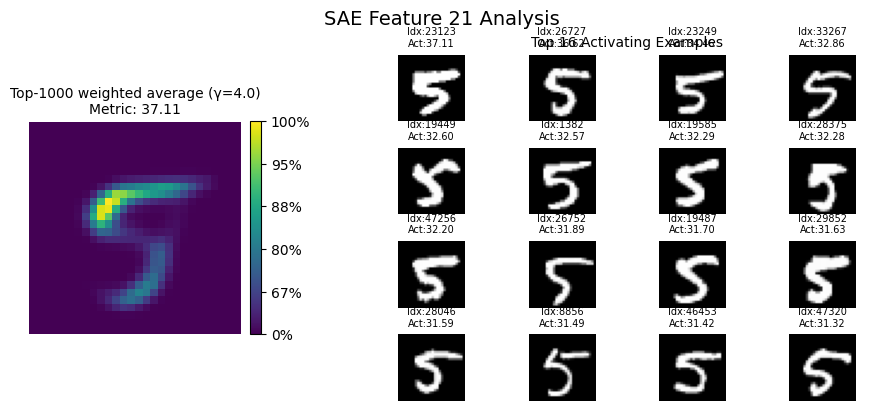

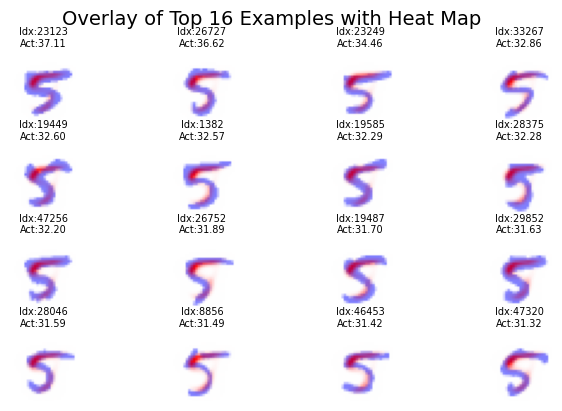

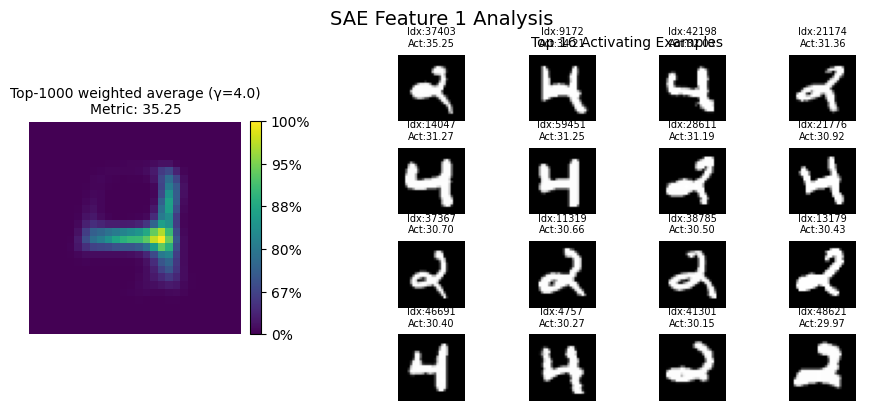

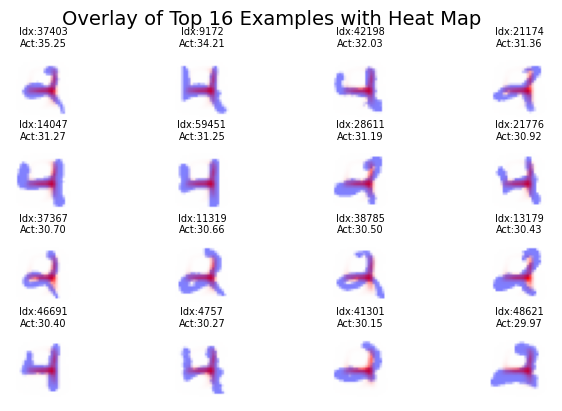

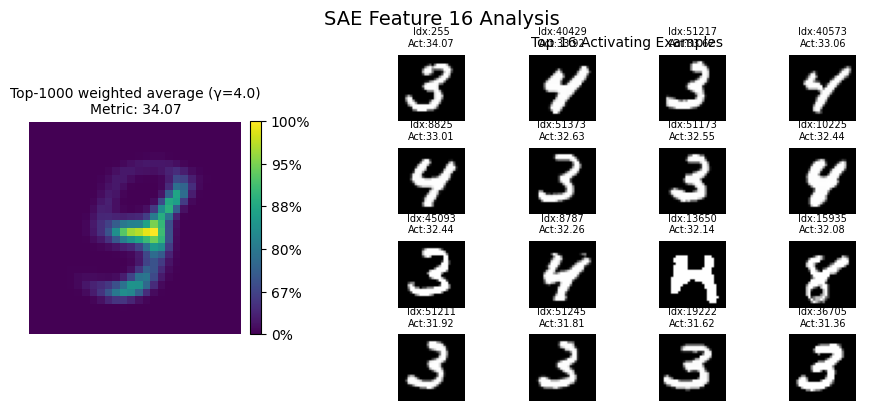

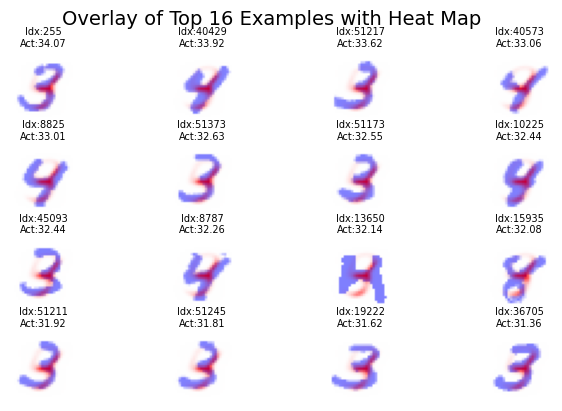

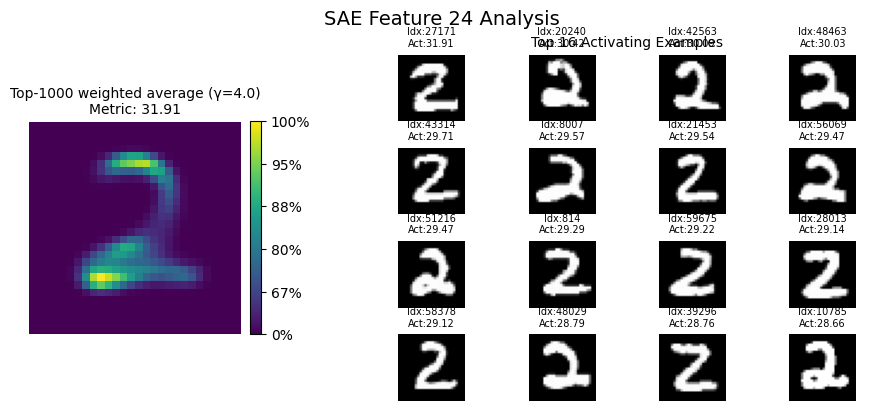

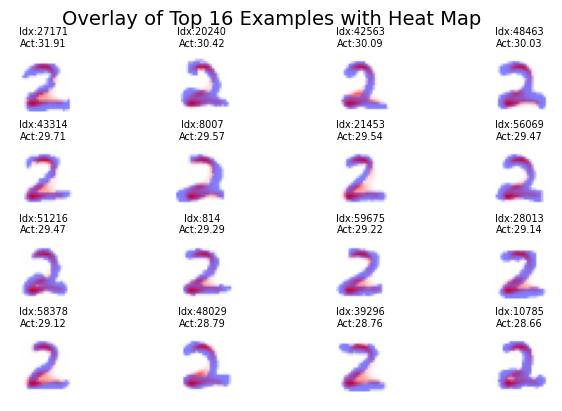

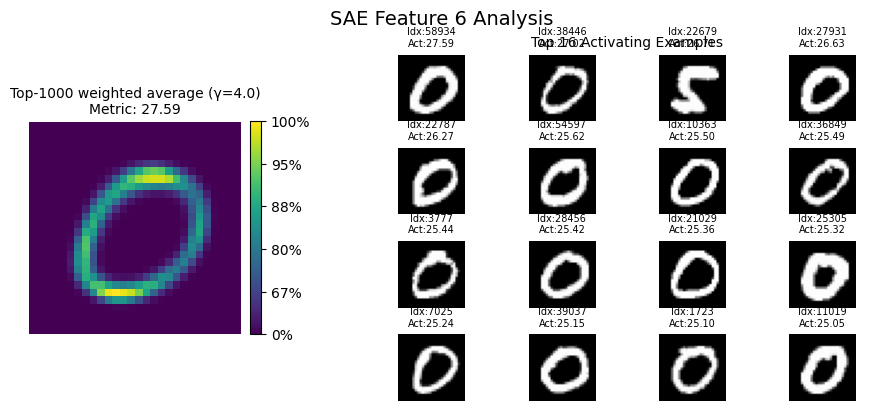

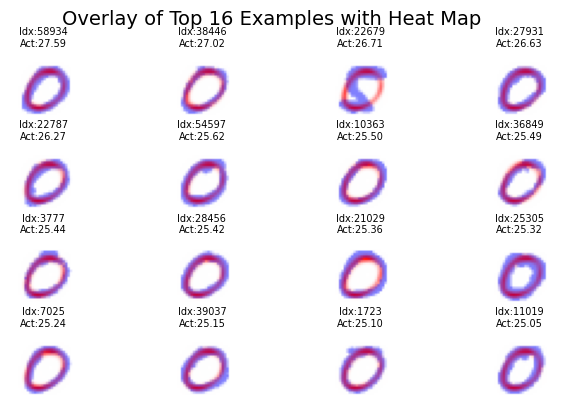

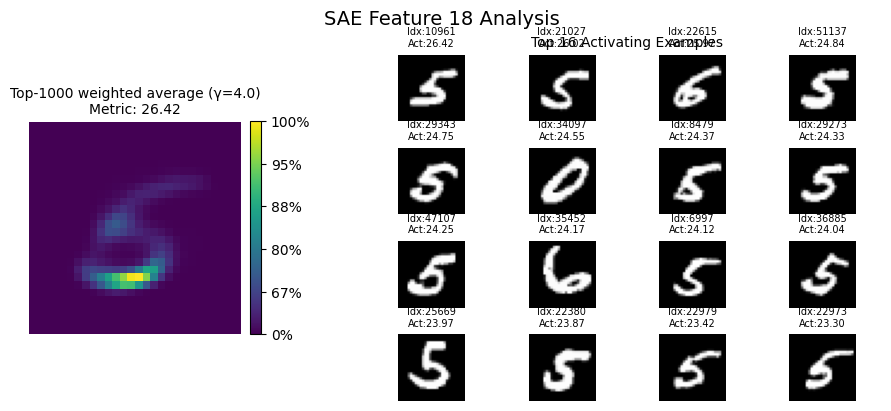

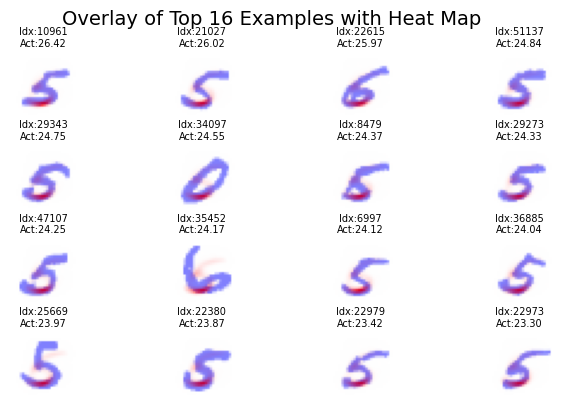

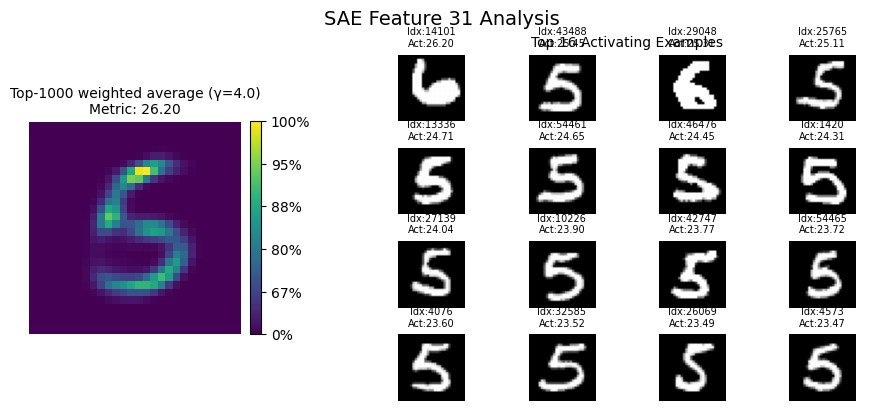

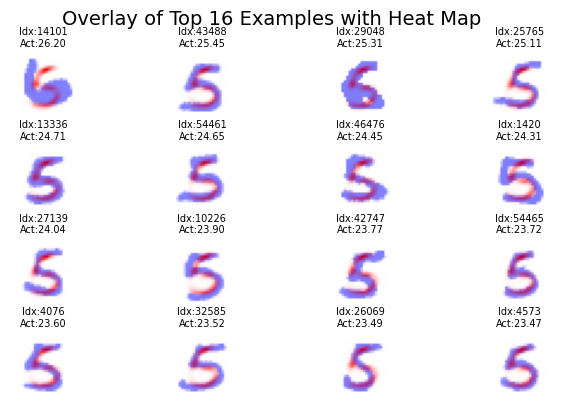

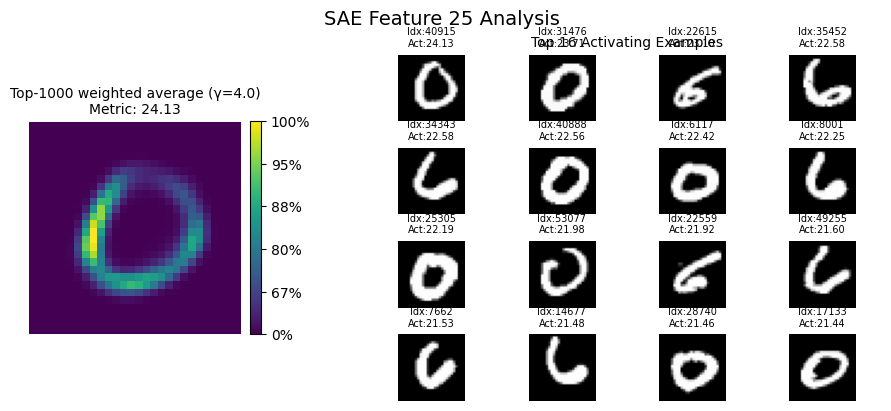

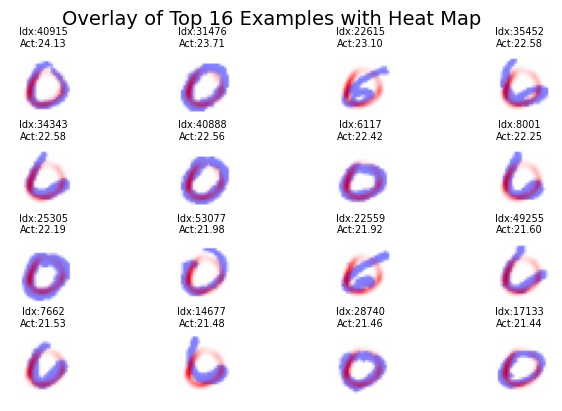

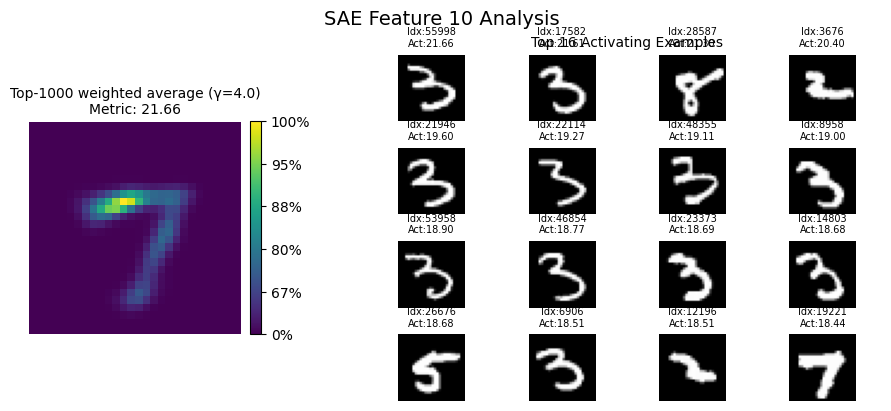

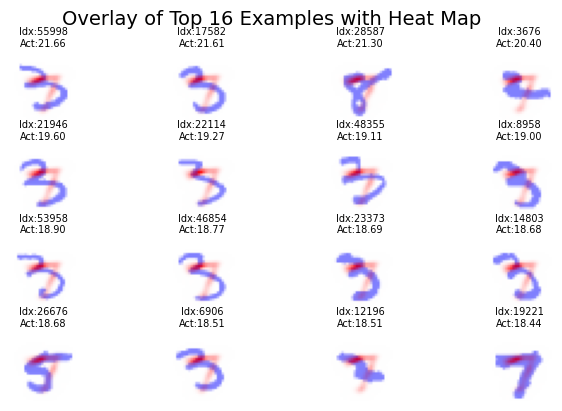

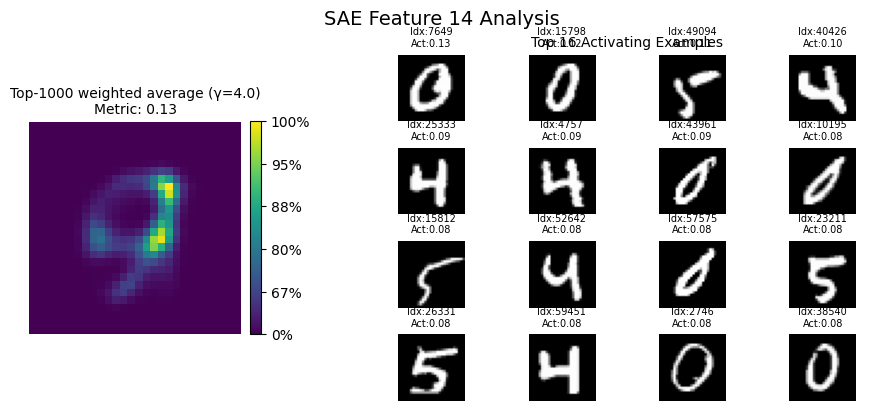

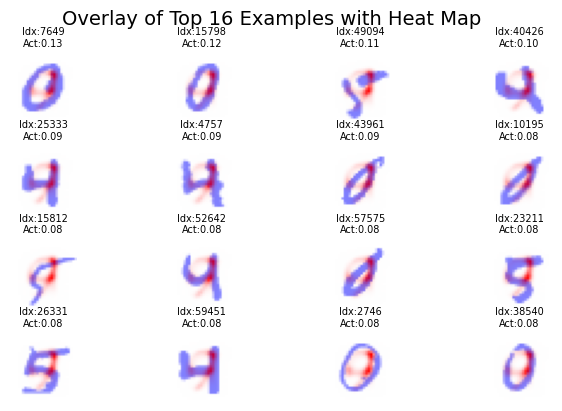


Visualization complete.


In [51]:
# --- Example Usage ---

if __name__ == "__main__":
    # Assume that MLP_out and SAE_out have been produced by training.
    trained_sae_model = SAE_out["trained_sae_model"]
    plot_config = {
        "trained_sae_model": trained_sae_model,
        "MLP_out": MLP_out,
        "NUM_FEATURES_TO_VISUALIZE": 10,
        "TOP_K_DISPLAY": 16,
        "TOP_K_WEIGHTED": 1000,
        "ENHANCEMENT_GAMMA": 4,
        "SORT_METRIC": "max_activation",
        "selected_layer_index_for_SAE": 1,  # MLP layer index used for training the SAE.
        
        # Choose the SAE submodule: "encoder", "decoder", or "full"
        "selected_sae_submodule": "decoder",  
        # Optional: specify an intermediate layer index within the chosen submodule.
        "selected_sae_layer_index": None,  
        "show_heatmap_overlay": True,
        "overlay_image_type": "enhanced",
        "overlay_digit_opacity": 0.5,
        "all_sae_acts": None,
        "data_dir": MLP_out.get("data_dir", "./data")
    }
    run_sae_visualization_from_config(plot_config)


# Similarity analysis by samples

SAE Cosine Similarity Matrix shape: (50, 50)


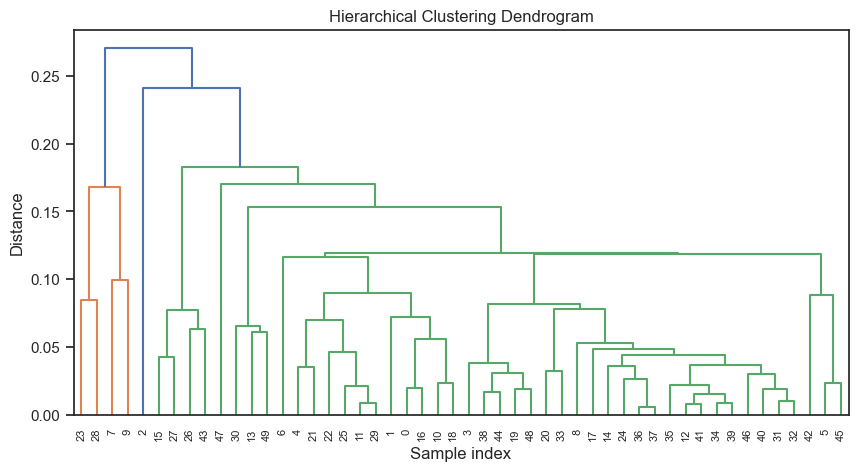

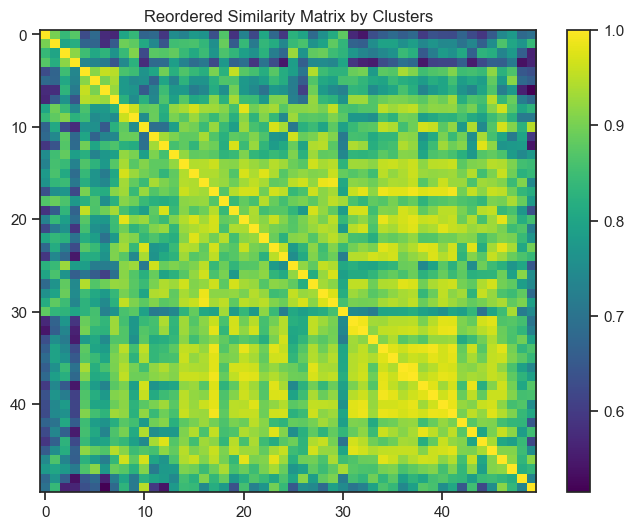

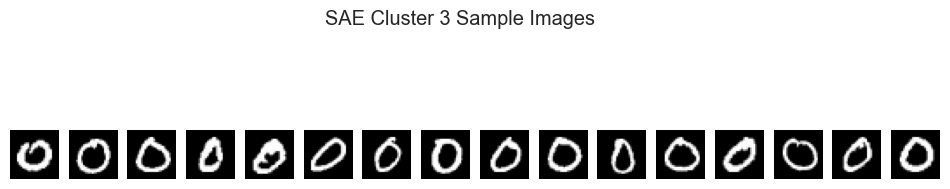

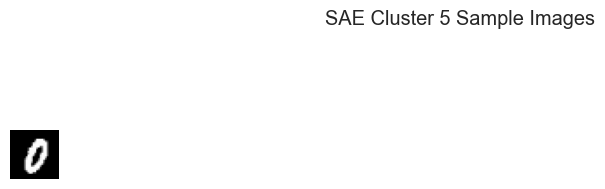

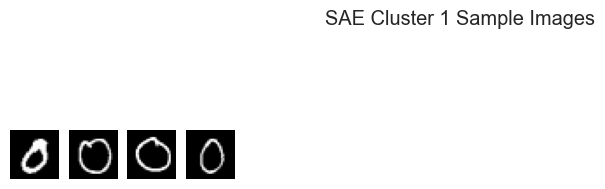

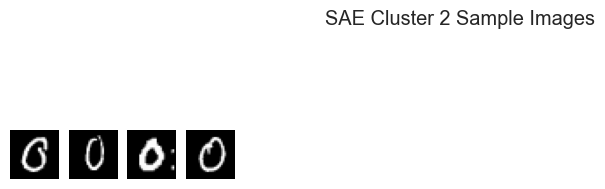

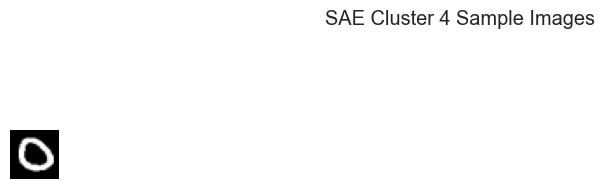

NTK Matrix shape: torch.Size([50, 50])


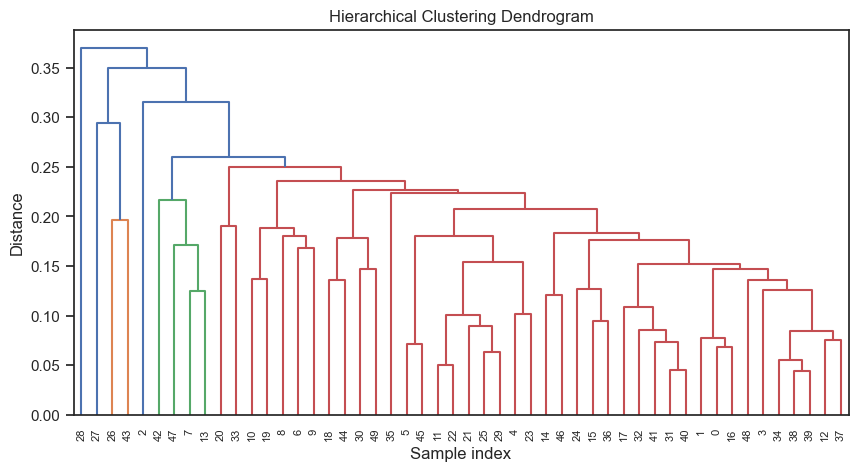

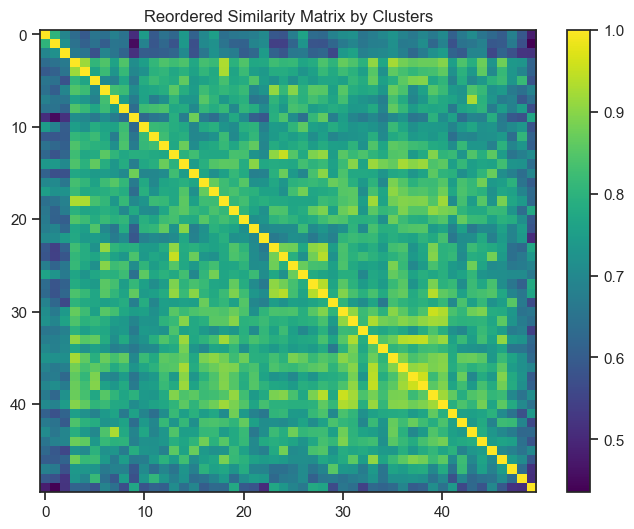

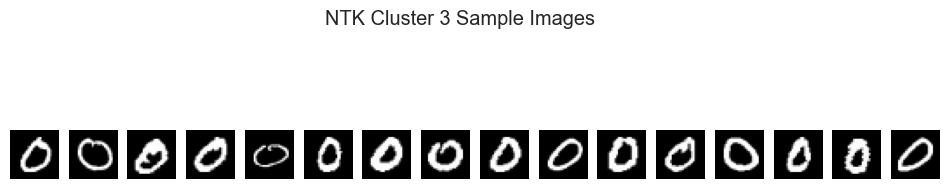

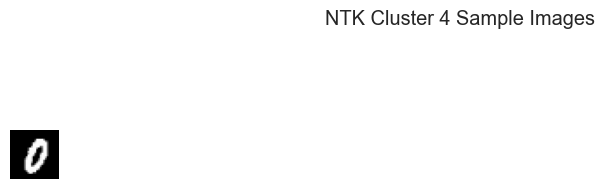

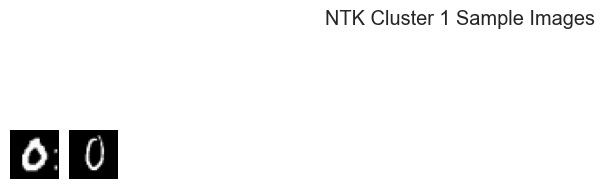

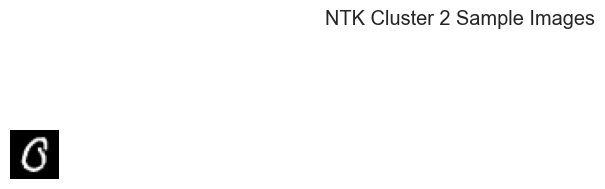

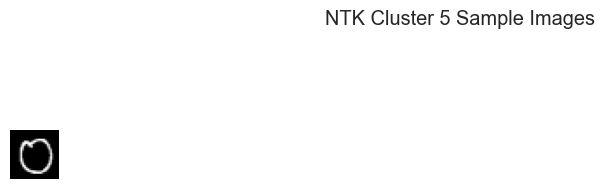

Contingency Matrix (rows: SAE clusters, cols: NTK clusters):
[[ 0.  0.  3.  0.  1.]
 [ 2.  1.  1.  0.  0.]
 [ 0.  0. 40.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  1.  0.]]


In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import random

##############################################
# Generic Subset Extraction                  #
##############################################

def get_subset_indices(train_dataset, label_value=1, sample_size=400):
    """
    Extract indices for samples in train_dataset with a specified label.
    """
    labels = torch.tensor([label for _, label in train_dataset])
    indices = (labels == label_value).nonzero(as_tuple=True)[0]
    return indices[:sample_size]

##############################################
# SAE Cosine Similarity Extraction           #
##############################################

def compute_sae_decoded_outputs(sae_model, normalized_activations, device):
    """
    Computes decoded outputs from the SAE.
    """
    sae_model.eval()
    with torch.no_grad():
        decoded_outputs = sae_model(normalized_activations.to(device))[0]
    return decoded_outputs.cpu()

def extract_sae_cosine_similarity(sae_model, normalized_activations, device, train_dataset, label_value=1, sample_size=400):
    """
    Extracts a cosine similarity matrix from SAE decoded outputs for samples with a given label.
    
    Returns a dictionary with:
      - "cosine_similarity_np": Cosine similarity matrix (NumPy array)
      - "subset_indices": The indices of the selected samples
    """
    subset_indices = get_subset_indices(train_dataset, label_value, sample_size)
    decoded_outputs = compute_sae_decoded_outputs(sae_model, normalized_activations, device)
    subset_decoded = decoded_outputs[subset_indices]
    
    norms = subset_decoded.norm(dim=1, keepdim=True)
    normalized_subset = subset_decoded / norms
    cosine_similarity_matrix = normalized_subset @ normalized_subset.t()
    cosine_similarity_np = cosine_similarity_matrix.numpy()
    
    print("SAE Cosine Similarity Matrix shape:", cosine_similarity_np.shape)
    return {"cosine_similarity_np": cosine_similarity_np, "subset_indices": subset_indices}

##############################################
# NTK Matrix Extraction                      #
##############################################

def run_ntk_for_extracted_subset(ntk_config, subset_indices):
    """
    Computes the NTK matrix (and its cosine-normalized version) for a subset of samples.
    
    ntk_config must include:
      - 'trained_model': the trained MLP model.
      - 'MLP_out': dict containing 'train_dataset_for_indexing'.
      - 'MLP_CONFIG': configuration dict (with 'num_classes').
      - 'DEVICE': torch.device.
      
    Returns a dictionary with:
      - "kernel_standard": raw NTK matrix.
      - "kernel_standard_norm": cosine normalized NTK matrix.
      - "subset_indices": the selected indices.
    """
    trained_model = ntk_config['trained_model']
    train_dataset = ntk_config['MLP_out']["train_dataset_for_indexing"]
    MLP_CONFIG = ntk_config['MLP_CONFIG']
    DEVICE = ntk_config['DEVICE']
    
    indices = subset_indices.tolist()
    subset = Subset(train_dataset, indices)
    loader = DataLoader(subset, batch_size=len(indices), shuffle=False)
    inputs, targets = next(iter(loader))
    
    kernel_standard = run_kernel_computation(model=trained_model, config=MLP_CONFIG, device=DEVICE, inputs=inputs)
    kernel_standard_norm = normalize_kernel(kernel_standard, method='cosine')
    print("NTK Matrix shape:", kernel_standard_norm.shape)
    
    return {
        "kernel_standard": kernel_standard,
        "kernel_standard_norm": kernel_standard_norm,
        "subset_indices": subset_indices
    }

##############################################
# Generic Clustering and Plotting Functions  #
##############################################

def perform_hierarchical_clustering(matrix_np, num_clusters=10):
    """
    Performs hierarchical clustering on a similarity matrix.
    
    Returns:
      - Z: linkage matrix
      - cluster_labels: cluster labels for each sample
      - sorted_indices: indices sorted by cluster label
      - sorted_matrix: reordered similarity matrix
    """
    distance_np = 1 - matrix_np
    np.fill_diagonal(distance_np, 0)
    condensed_distance = squareform(distance_np)
    
    Z = linkage(condensed_distance, method='average')
    
    plt.figure(figsize=(10, 5))
    dendrogram(Z)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Sample index")
    plt.ylabel("Distance")
    plt.show()
    
    cluster_labels = fcluster(Z, t=num_clusters, criterion='maxclust')
    sorted_indices = sorted(range(len(cluster_labels)), key=lambda i: cluster_labels[i])
    sorted_matrix = matrix_np[np.ix_(sorted_indices, sorted_indices)]
    
    plt.figure(figsize=(8, 6))
    plt.imshow(sorted_matrix, cmap='viridis', aspect='auto')
    plt.title("Reordered Similarity Matrix by Clusters")
    plt.colorbar()
    plt.show()
    
    return {"Z": Z, "cluster_labels": cluster_labels, "sorted_indices": sorted_indices, "sorted_matrix": sorted_matrix}

def plot_cluster_sample_images(cluster_labels, subset_indices, train_dataset, num_sample_images=4, title_prefix="Cluster"):
    """
    For each cluster, randomly samples and displays images.
    """
    cluster_to_indices = {}
    for i, cl in enumerate(cluster_labels):
        cluster_to_indices.setdefault(cl, []).append(subset_indices[i].item())
    
    for cl, indices in cluster_to_indices.items():
        sample_indices = random.sample(indices, min(num_sample_images, len(indices)))
        plt.figure(figsize=(12, 3))
        for j, idx in enumerate(sample_indices):
            plt.subplot(1, num_sample_images, j+1)
            img, _ = train_dataset[idx]
            if torch.is_tensor(img):
                img = img.squeeze().numpy()
            plt.imshow(img, cmap='gray')
            plt.axis('off')
        plt.suptitle(f"{title_prefix} {cl} Sample Images")
        plt.show()

def clustering_and_plotting(similarity_dict, train_dataset, num_clusters=10, num_sample_images=4, title_prefix="Cluster"):
    """
    Generic wrapper to perform clustering on a similarity matrix and plot results.
    Also returns the clustering information for downstream use.
    """
    if "cosine_similarity_np" in similarity_dict:
        sim_matrix = similarity_dict["cosine_similarity_np"]
    elif "kernel_standard_norm" in similarity_dict:
        sim_matrix = similarity_dict["kernel_standard_norm"].cpu().numpy()
    else:
        raise ValueError("No recognized similarity matrix found in input dictionary.")
    
    subset_indices = similarity_dict["subset_indices"]
    
    clustering_out = perform_hierarchical_clustering(sim_matrix, num_clusters)
    plot_cluster_sample_images(clustering_out["cluster_labels"], subset_indices, train_dataset, num_sample_images, title_prefix)
    
    # Return full clustering information for downstream analysis
    return {"similarity_dict": similarity_dict, "clustering_out": clustering_out}

##############################################
# Wrappers for SAE and NTK Analysis          #
##############################################

def sae_clustering_analysis(sae_model, normalized_activations, device, train_dataset, label_value=1, sample_size=400, num_clusters=10, num_sample_images=4):
    """
    Wrapper to extract SAE cosine similarity and perform clustering analysis.
    Returns the clustering information for downstream use.
    """
    extraction = extract_sae_cosine_similarity(sae_model, normalized_activations, device, train_dataset, label_value, sample_size)
    clustering_info = clustering_and_plotting(extraction, train_dataset, num_clusters, num_sample_images, title_prefix="SAE Cluster")
    return clustering_info

def ntk_clustering_analysis(ntk_config, train_dataset, label_value=1, sample_size=400, num_clusters=10, num_sample_images=4):
    """
    Wrapper to extract NTK similarity for a given subset and perform clustering analysis.
    Returns the clustering information for downstream use.
    """
    subset_indices = get_subset_indices(train_dataset, label_value, sample_size)
    ntk_extraction = run_ntk_for_extracted_subset(ntk_config, subset_indices)
    clustering_info = clustering_and_plotting(ntk_extraction, train_dataset, num_clusters, num_sample_images, title_prefix="NTK Cluster")
    return clustering_info

##############################################
# Cluster Comparison Function                #
##############################################

def compare_clusterings(result1, result2):
    """
    Compares two clustering results (assumed to be produced on the same subset).
    
    Both result1 and result2 should be dictionaries returned by clustering_and_plotting
    and contain:
      - "clustering_out": with key "cluster_labels"
      - "similarity_dict": with key "subset_indices"
    
    This function computes a contingency table showing the overlap between clusters.
    """
    labels1 = result1["clustering_out"]["cluster_labels"]
    labels2 = result2["clustering_out"]["cluster_labels"]
    indices = result1["similarity_dict"]["subset_indices"].tolist()
    
    unique1 = np.unique(labels1)
    unique2 = np.unique(labels2)
    
    contingency = {}
    for cl1 in unique1:
        for cl2 in unique2:
            # Count the number of samples with cluster label cl1 in result1 and cl2 in result2
            count = sum((labels1[i] == cl1) and (labels2[i] == cl2) for i in range(len(indices)))
            contingency[(cl1, cl2)] = count
    
    # Optionally: Convert to a matrix for better visualization.
    contingency_matrix = np.zeros((len(unique1), len(unique2)))
    for i, cl1 in enumerate(unique1):
        for j, cl2 in enumerate(unique2):
            contingency_matrix[i, j] = contingency[(cl1, cl2)]
    
    print("Contingency Matrix (rows: SAE clusters, cols: NTK clusters):")
    print(contingency_matrix)
    return contingency_matrix

##############################################
# Example Usage:
##############################################

# Assume the following are defined:
# SAE_out: dict from train_SAE() with keys "trained_sae_model", "normalized_activations", "DEVICE"
# MLP_out: dict from train_MLP() with key "train_dataset_for_indexing"
# ntk_config: dict containing 'trained_model', 'MLP_out', 'MLP_CONFIG', 'DEVICE'

#SPLIT


# Config for clustering analysis
clustering_config = {
    "label_value": 0,       # Digit/label to select
    "sample_size": 50,     # Number of samples to extract
    "num_clusters": 5,      # Number of clusters to compute
    "num_sample_images": 16  # Number of sample images to display per cluster
}

# Run SAE clustering analysis using the config
sae_cluster_result = sae_clustering_analysis(
    sae_model=SAE_out["trained_sae_model"],
    normalized_activations=SAE_out["normalized_activations"],
    device=SAE_out["DEVICE"],
    train_dataset=MLP_out["train_dataset_for_indexing"],
    label_value=clustering_config["label_value"],
    sample_size=clustering_config["sample_size"],
    num_clusters=clustering_config["num_clusters"],
    num_sample_images=clustering_config["num_sample_images"]
)

# Run NTK clustering analysis using the same config
ntk_cluster_result = ntk_clustering_analysis(
    ntk_config=ntk_config,
    train_dataset=MLP_out["train_dataset_for_indexing"],
    label_value=clustering_config["label_value"],
    sample_size=clustering_config["sample_size"],
    num_clusters=clustering_config["num_clusters"],
    num_sample_images=clustering_config["num_sample_images"]
)


# Compare the two clustering results
contingency_matrix = compare_clusterings(sae_cluster_result, ntk_cluster_result)

# Now you have:
# - sae_cluster_result and ntk_cluster_result with all the clustering outputs,
# - contingency_matrix showing the overlaps between SAE and NTK clusters.


# attempt find matching clusters

Contingency Matrix (rows: SAE clusters, cols: NTK clusters):
[[ 0.  0.  3.  0.  1.]
 [ 2.  1.  1.  0.  0.]
 [ 0.  0. 40.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  1.  0.]]
Optimal matching (Hungarian): {1: 5, 2: 1, 3: 3, 4: 2, 5: 4}

Matched SAE Cluster 1 & NTK Cluster 5:
  SAE cluster size: 4
  NTK cluster size: 1
  Shared: 1 samples
  SAE Unique: 3 samples
  NTK Unique: 0 samples


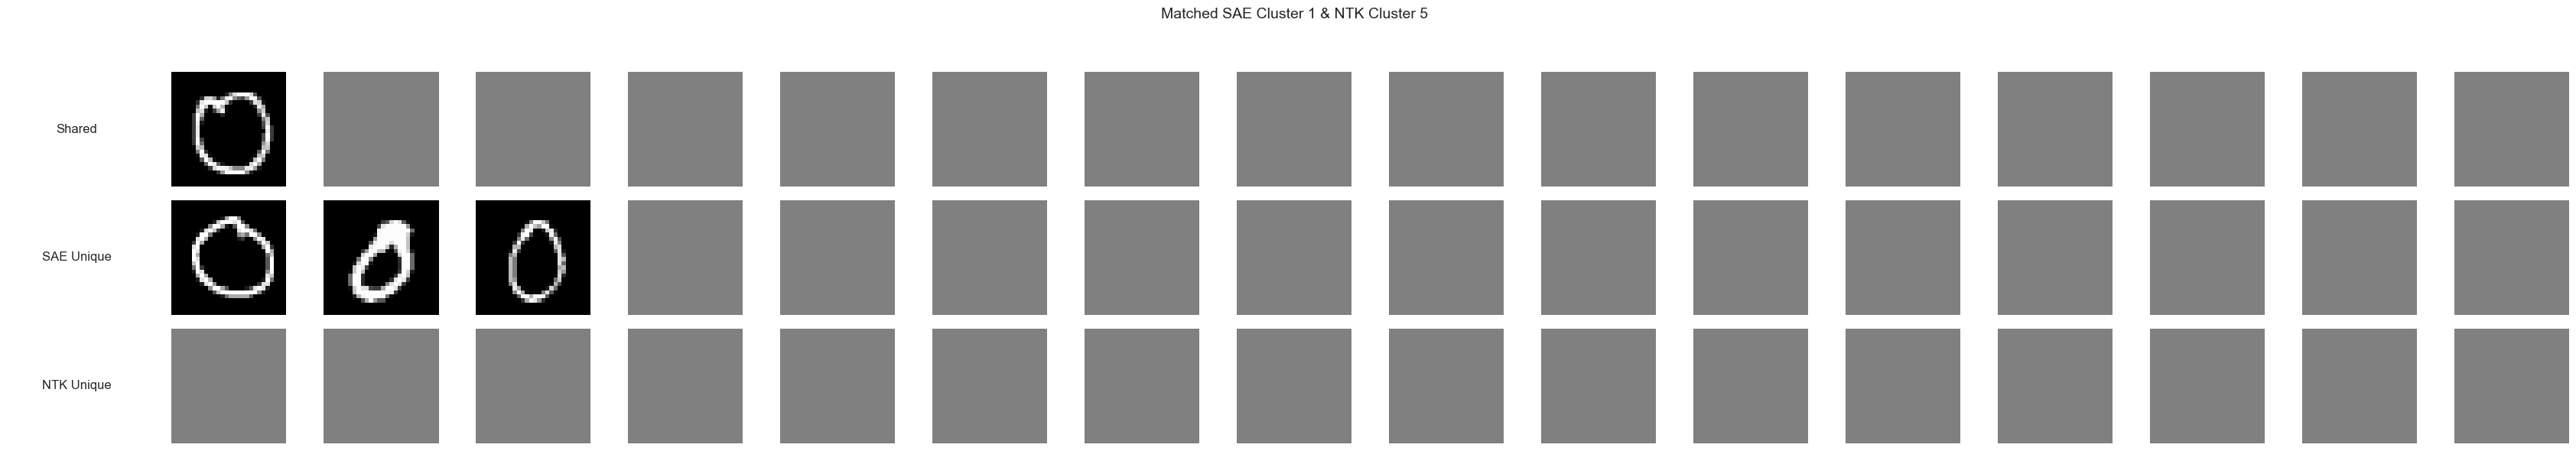


Matched SAE Cluster 2 & NTK Cluster 1:
  SAE cluster size: 4
  NTK cluster size: 2
  Shared: 2 samples
  SAE Unique: 2 samples
  NTK Unique: 0 samples


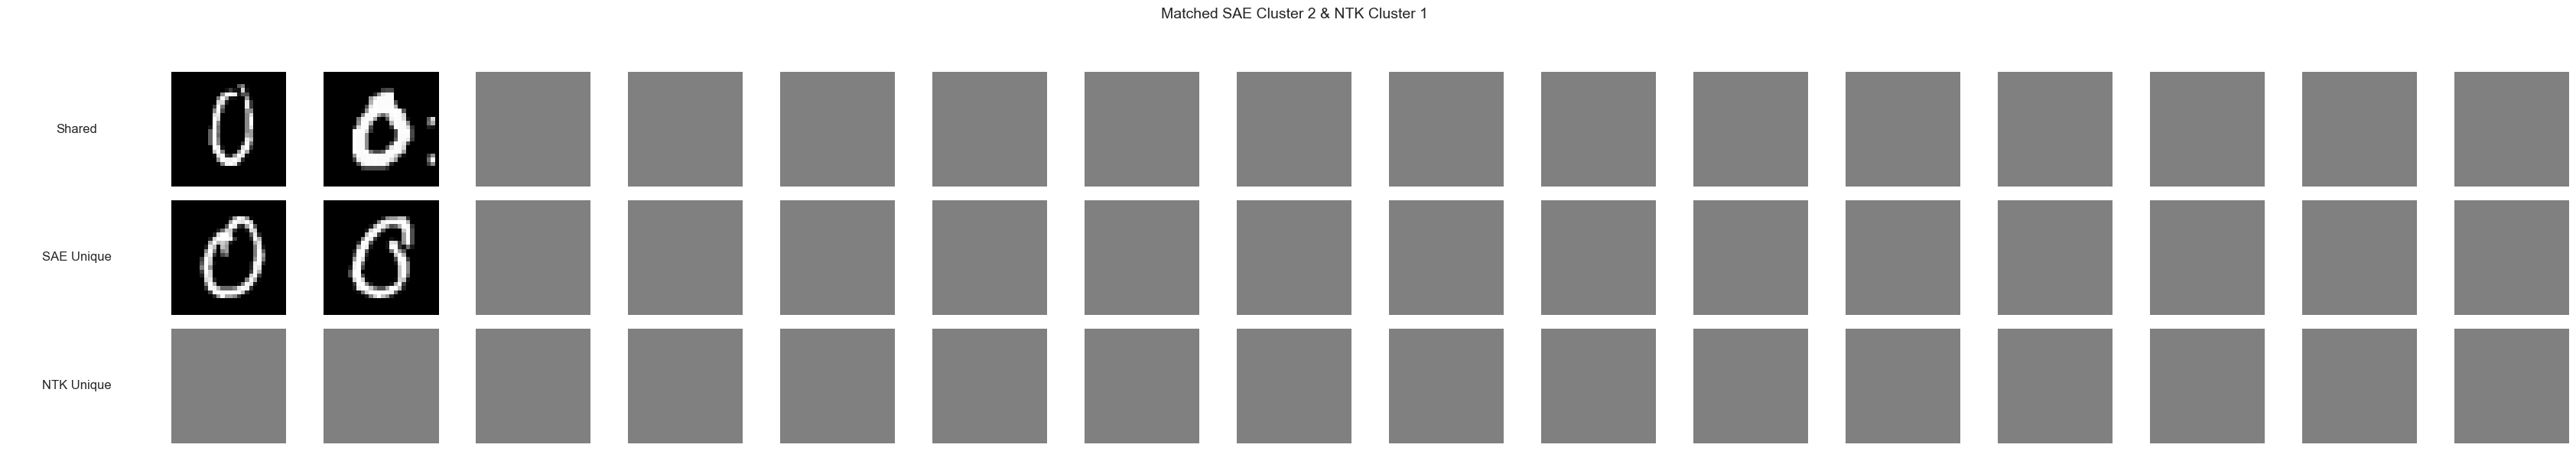


Matched SAE Cluster 3 & NTK Cluster 3:
  SAE cluster size: 40
  NTK cluster size: 45
  Shared: 40 samples
  SAE Unique: 0 samples
  NTK Unique: 5 samples


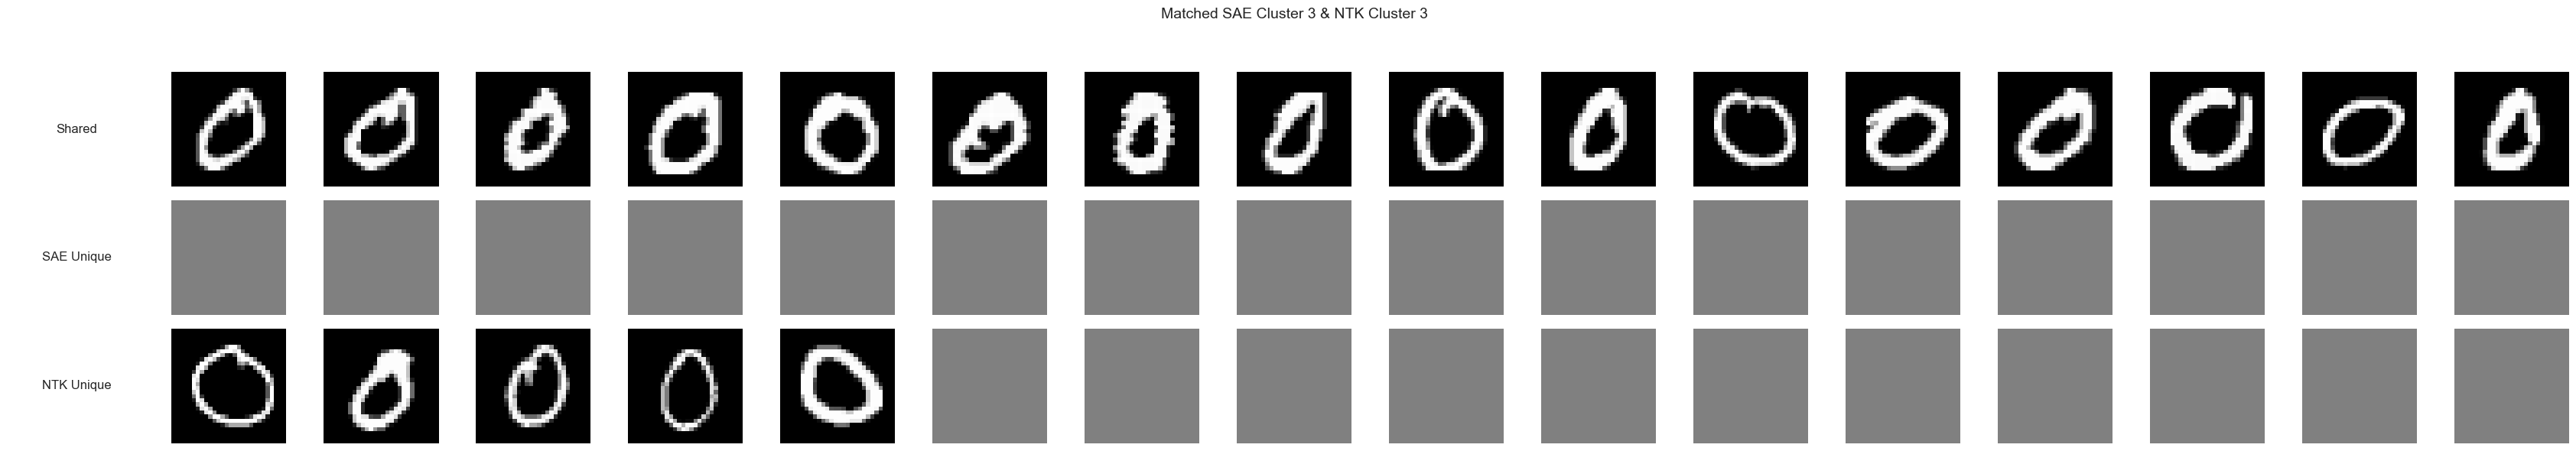


Matched SAE Cluster 4 & NTK Cluster 2:
  SAE cluster size: 1
  NTK cluster size: 1
  Shared: 0 samples
  SAE Unique: 1 samples
  NTK Unique: 1 samples


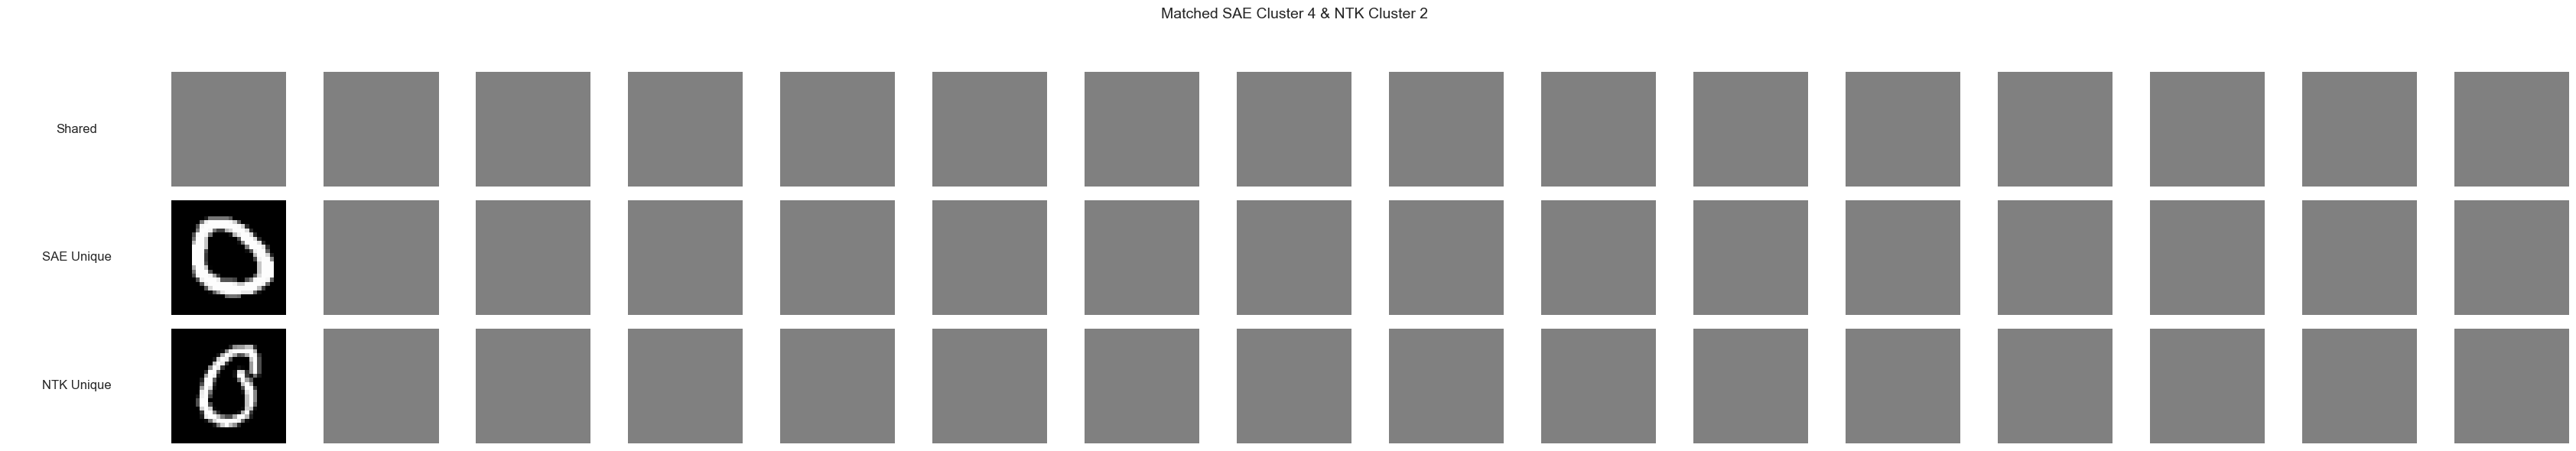


Matched SAE Cluster 5 & NTK Cluster 4:
  SAE cluster size: 1
  NTK cluster size: 1
  Shared: 1 samples
  SAE Unique: 0 samples
  NTK Unique: 0 samples


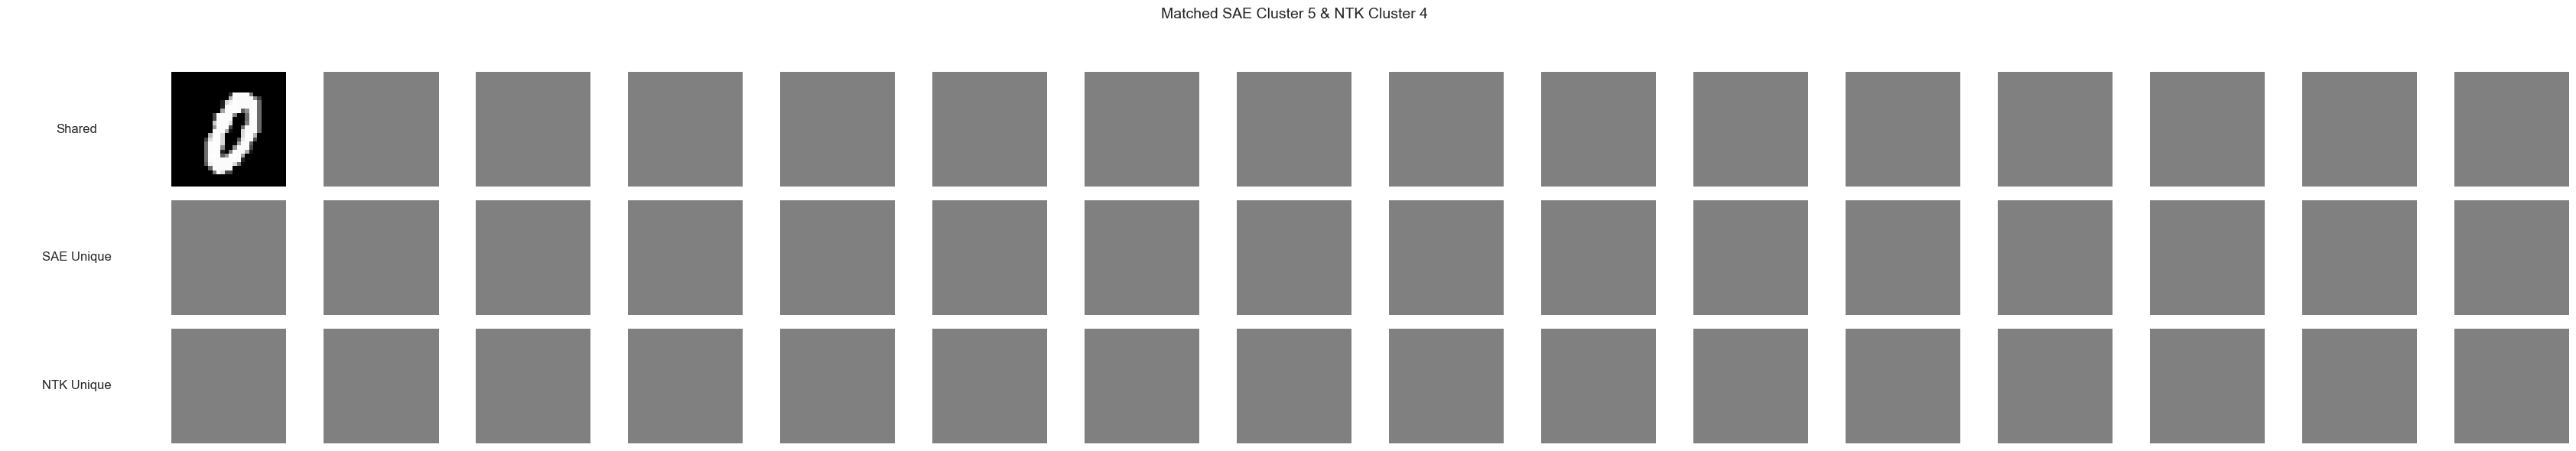

In [52]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import random
from scipy.optimize import linear_sum_assignment

def match_clusters_hungarian(sae_labels, ntk_labels):
    """
    Matches clusters between SAE and NTK using the Hungarian algorithm.
    
    Args:
      sae_labels: Array of cluster labels from SAE clustering.
      ntk_labels: Array of cluster labels from NTK clustering.
      
    Returns:
      matching: A dictionary mapping each unique SAE cluster to the matched NTK cluster.
      contingency_matrix: The contingency matrix used for matching.
    """
    unique_sae = np.unique(sae_labels)
    unique_ntk = np.unique(ntk_labels)
    contingency_matrix = np.zeros((len(unique_sae), len(unique_ntk)))
    
    for i, cl1 in enumerate(unique_sae):
        for j, cl2 in enumerate(unique_ntk):
            count = np.sum((sae_labels == cl1) & (ntk_labels == cl2))
            contingency_matrix[i, j] = count

    cost_matrix = -contingency_matrix
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    matching = {}
    for i, j in zip(row_ind, col_ind):
        matching[unique_sae[i]] = unique_ntk[j]
    
    return matching, contingency_matrix

def get_default_gray_image(train_dataset):
    """
    Returns a default gray image with the same shape as the first image in train_dataset.
    """
    first_img, _ = train_dataset[0]
    if torch.is_tensor(first_img):
        first_img = first_img.squeeze().numpy()
    # Create a gray image (value 0.5) with the same shape.
    gray_img = np.full(first_img.shape, 0.5)
    return gray_img

def compare_clusters_hungarian_visualize(sae_result, ntk_result, train_dataset, num_shared=4, num_unique=4):
    """
    Matches clusters from SAE and NTK using the Hungarian algorithm and creates one figure
    per matched pair with three rows:
      - Row 1: Shared images between the matched clusters.
      - Row 2: Images unique to the SAE cluster.
      - Row 3: Images unique to the NTK cluster.
    
    Each row is displayed as a grid of fixed cells (with an extra column for a row label).
    If a cell has no image data, a default gray image is displayed.
    
    In addition, the function prints out the size (number of samples) of each category.
    
    Returns:
      matching: Dictionary with the optimal matching.
      contingency_matrix: The contingency matrix.
    """
    sae_labels = np.array(sae_result["clustering_out"]["cluster_labels"])
    ntk_labels = np.array(ntk_result["clustering_out"]["cluster_labels"])
    subset_indices = sae_result["similarity_dict"]["subset_indices"].tolist()  # assumed same for both

    matching, contingency_matrix = match_clusters_hungarian(sae_labels, ntk_labels)
    print("Contingency Matrix (rows: SAE clusters, cols: NTK clusters):")
    print(contingency_matrix)
    print("Optimal matching (Hungarian):", matching)
    
    default_gray = get_default_gray_image(train_dataset)
    
    # Define row labels.
    row_labels = ["Shared", "SAE Unique", "NTK Unique"]
    
    # For each matched pair, create a combined figure.
    for sae_cl, ntk_cl in matching.items():
        indices_sae = [i for i, lbl in enumerate(sae_labels) if lbl == sae_cl]
        indices_ntk = [i for i, lbl in enumerate(ntk_labels) if lbl == ntk_cl]
        
        shared = sorted(list(set(indices_sae) & set(indices_ntk)))
        unique_sae = sorted(list(set(indices_sae) - set(shared)))
        unique_ntk = sorted(list(set(indices_ntk) - set(shared)))
        
        # Print cluster sizes.
        print(f"\nMatched SAE Cluster {sae_cl} & NTK Cluster {ntk_cl}:")
        print(f"  SAE cluster size: {len(indices_sae)}")
        print(f"  NTK cluster size: {len(indices_ntk)}")
        print(f"  Shared: {len(shared)} samples")
        print(f"  SAE Unique: {len(unique_sae)} samples")
        print(f"  NTK Unique: {len(unique_ntk)} samples")
        
        # Convert positions in the subset to actual dataset indices.
        shared_dataset = [subset_indices[i] for i in shared]
        unique_sae_dataset = [subset_indices[i] for i in unique_sae]
        unique_ntk_dataset = [subset_indices[i] for i in unique_ntk]
        
        # Determine number of columns (cells) to show.
        ncols = max(num_shared, num_unique)
        
        # Create a figure with 3 rows and ncols+1 columns (extra column for row labels).
        fig, axs = plt.subplots(3, ncols+1, figsize=((ncols+1)*2, 6))
        fig.suptitle(f"Matched SAE Cluster {sae_cl} & NTK Cluster {ntk_cl}", fontsize=14)
        
        # Helper function to plot a row.
        def plot_row(axs_row, dataset_indices, label):
            # First column: row label.
            axs_row[0].axis('off')
            axs_row[0].text(0.5, 0.5, label, ha='center', va='center', fontsize=12)
            # Remaining cells.
            for j in range(1, ncols+1):
                ax = axs_row[j]
                ax.axis('off')
                if j-1 < len(dataset_indices):
                    img, _ = train_dataset[dataset_indices[j-1]]
                    if torch.is_tensor(img):
                        img = img.squeeze().numpy()
                    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
                else:
                    ax.imshow(default_gray, cmap='gray', vmin=0, vmax=1)
        
        plot_row(axs[0], shared_dataset, "Shared")
        plot_row(axs[1], unique_sae_dataset, "SAE Unique")
        plot_row(axs[2], unique_ntk_dataset, "NTK Unique")
        
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()
    
    return matching, contingency_matrix

# Example usage:
matching_info, contingency_matrix = compare_clusters_hungarian_visualize(
    sae_result=sae_cluster_result,
    ntk_result=ntk_cluster_result,
    train_dataset=MLP_out["train_dataset_for_indexing"],
    num_shared=16,
    num_unique=16
)


# RUN SAE grid search

In [16]:

# Create your GRID_CONFIG without creating fake inputs.
# For example, you can supply your own MLP_CONFIG and MLP_out.
GRID_CONFIG = {
    "SAE_CONFIG_grid": {
        "selected_layer_index": [1],  # index of MLP layer to use
        "SAE_scale_factor": [4],      # if provided, SAE hidden_size = MLP_CONFIG['hidden_layers'][selected_index]*scale_factor
        "learning_rate": [0.0001],
        "batch_size": [64],
        "num_epochs": [10],
        "l1_coeff": [0.1, 2, 4, 8],
        "l2_coeff": [0.01, 0.1, 1, 2]
    },
    "MLP_CONFIG": MLP_CONFIG,
    "MLP_out": MLP_out
}
GRID_out = grid_search_SAE(GRID_CONFIG)
print("\nBest SAE configuration based on final loss:")
print(GRID_out["best_result"]["SAE_config"])
print(f"Final SAE Loss: {GRID_out['best_result']['final_loss']:.6f}")



Testing SAE configuration: {'selected_layer_index': 1, 'SAE_scale_factor': 4, 'learning_rate': 0.0001, 'batch_size': 64, 'num_epochs': 10, 'l1_coeff': 0.1, 'l2_coeff': 0.01}


--- Initializing SAE ---
Using SAE input size: 32 (from MLP hidden layer index 1)
Normalizing activation data...

--- SAE Model Architecture ---
SAE(
  (encoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
  )
  (decoder): Linear(in_features=128, out_features=32, bias=True)
)
Input: 32, Hidden: 128
LR: 0.0001, L1: 0.1, L2: 0.01
----------------------------

SAE Epoch 1 Avg Loss -> Total: 0.379253, MSE: 0.348267, L1: 0.283016, L2: 0.268475, L0 Sparsity: 0.4957
Epoch 1: Practical Reconstruction MSE = 0.097211
SAE Epoch 2 Avg Loss -> Total: 0.103714, MSE: 0.066716, L1: 0.334515, L2: 0.354584, L0 Sparsity: 0.5104
Epoch 2: Practical Reconstruction MSE = 0.038222
SAE Epoch 3 Avg Loss -> Total: 0.069477, MSE: 0.033775, L1: 0.324241, L2: 0.327803, L0 Sparsity: 0.5201
Epoch 3

# PLOT SAE grid search

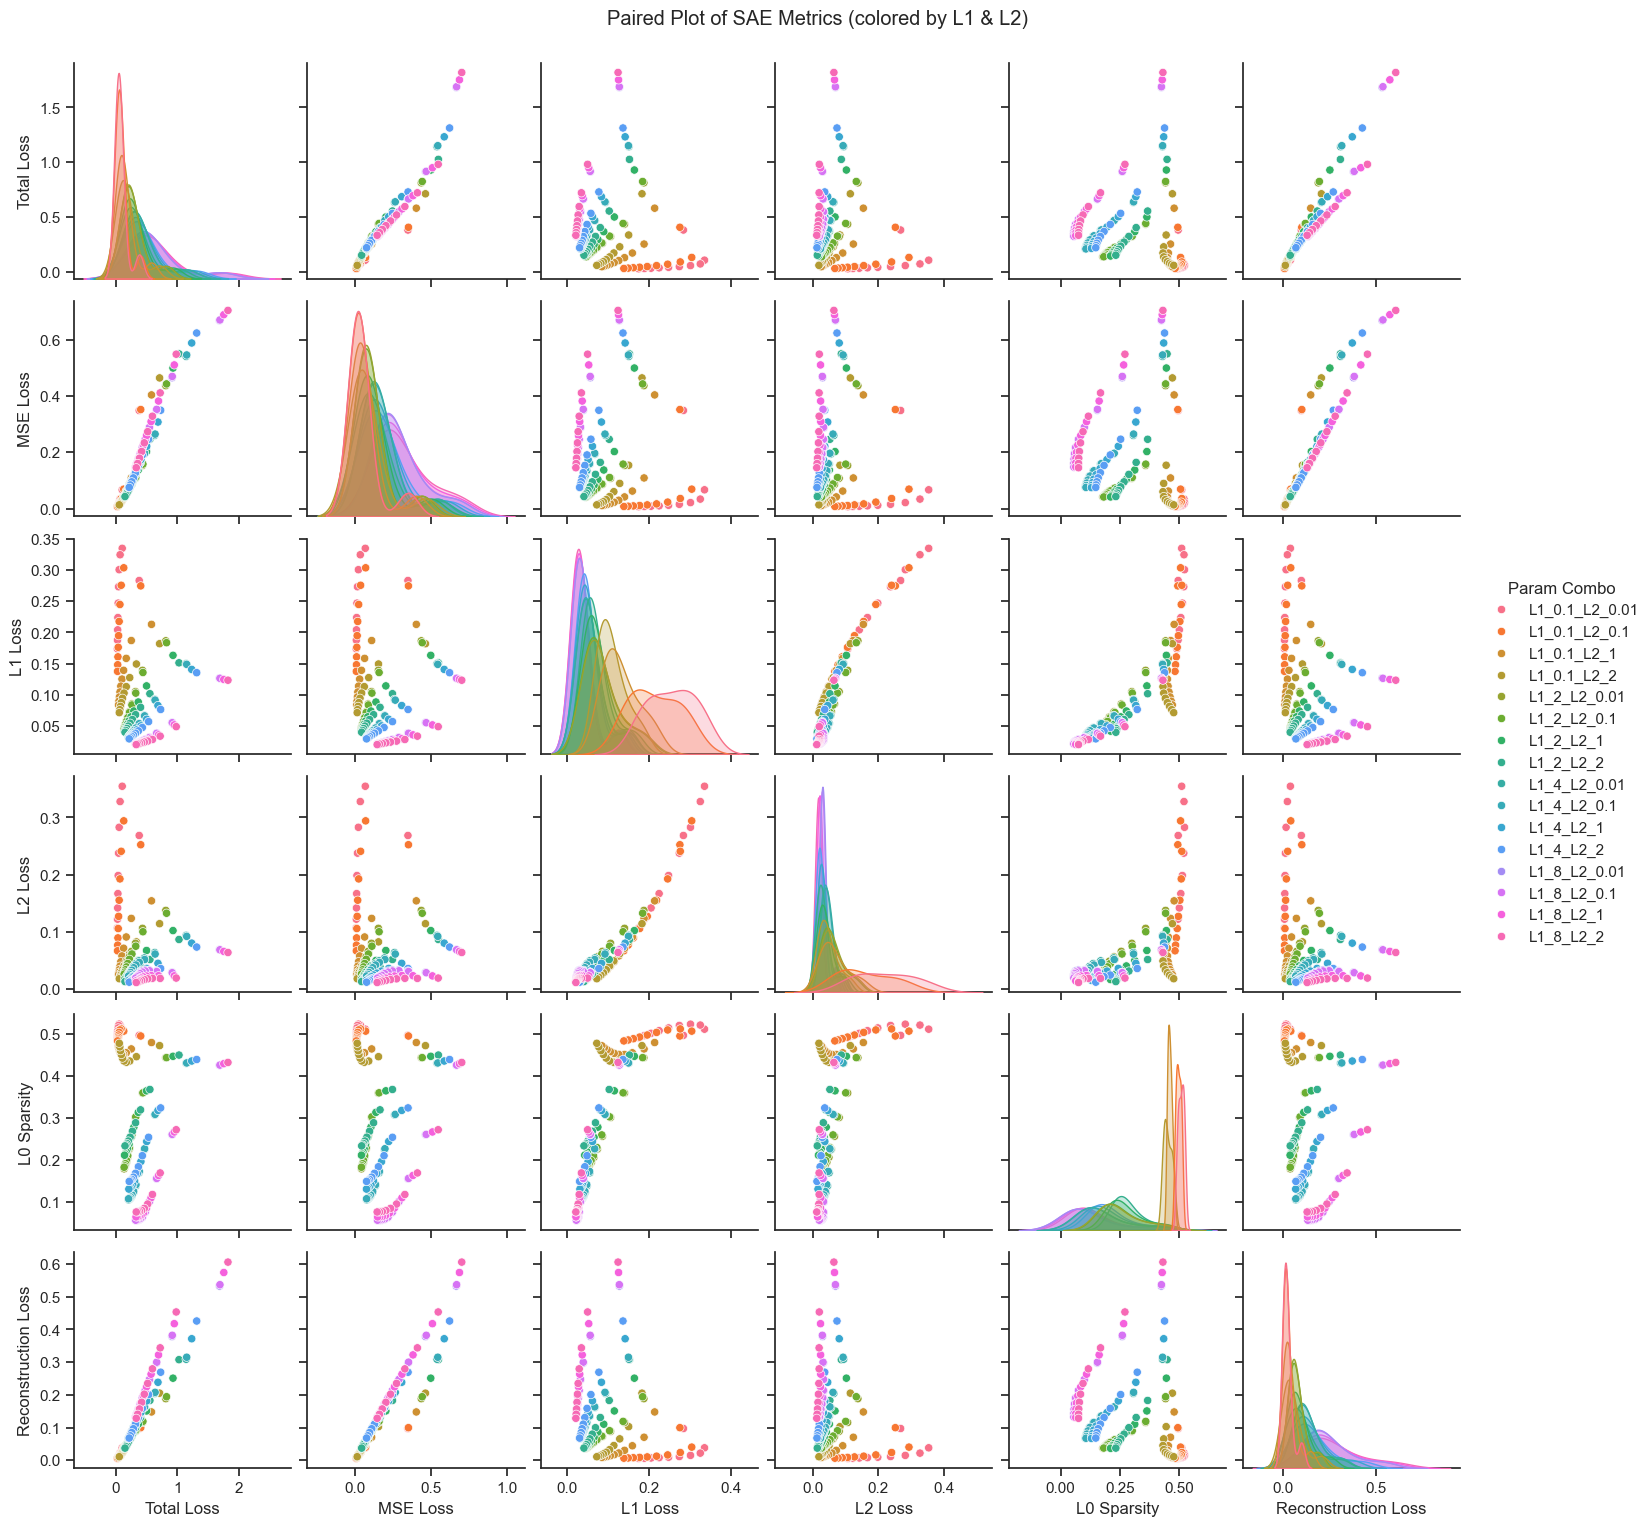

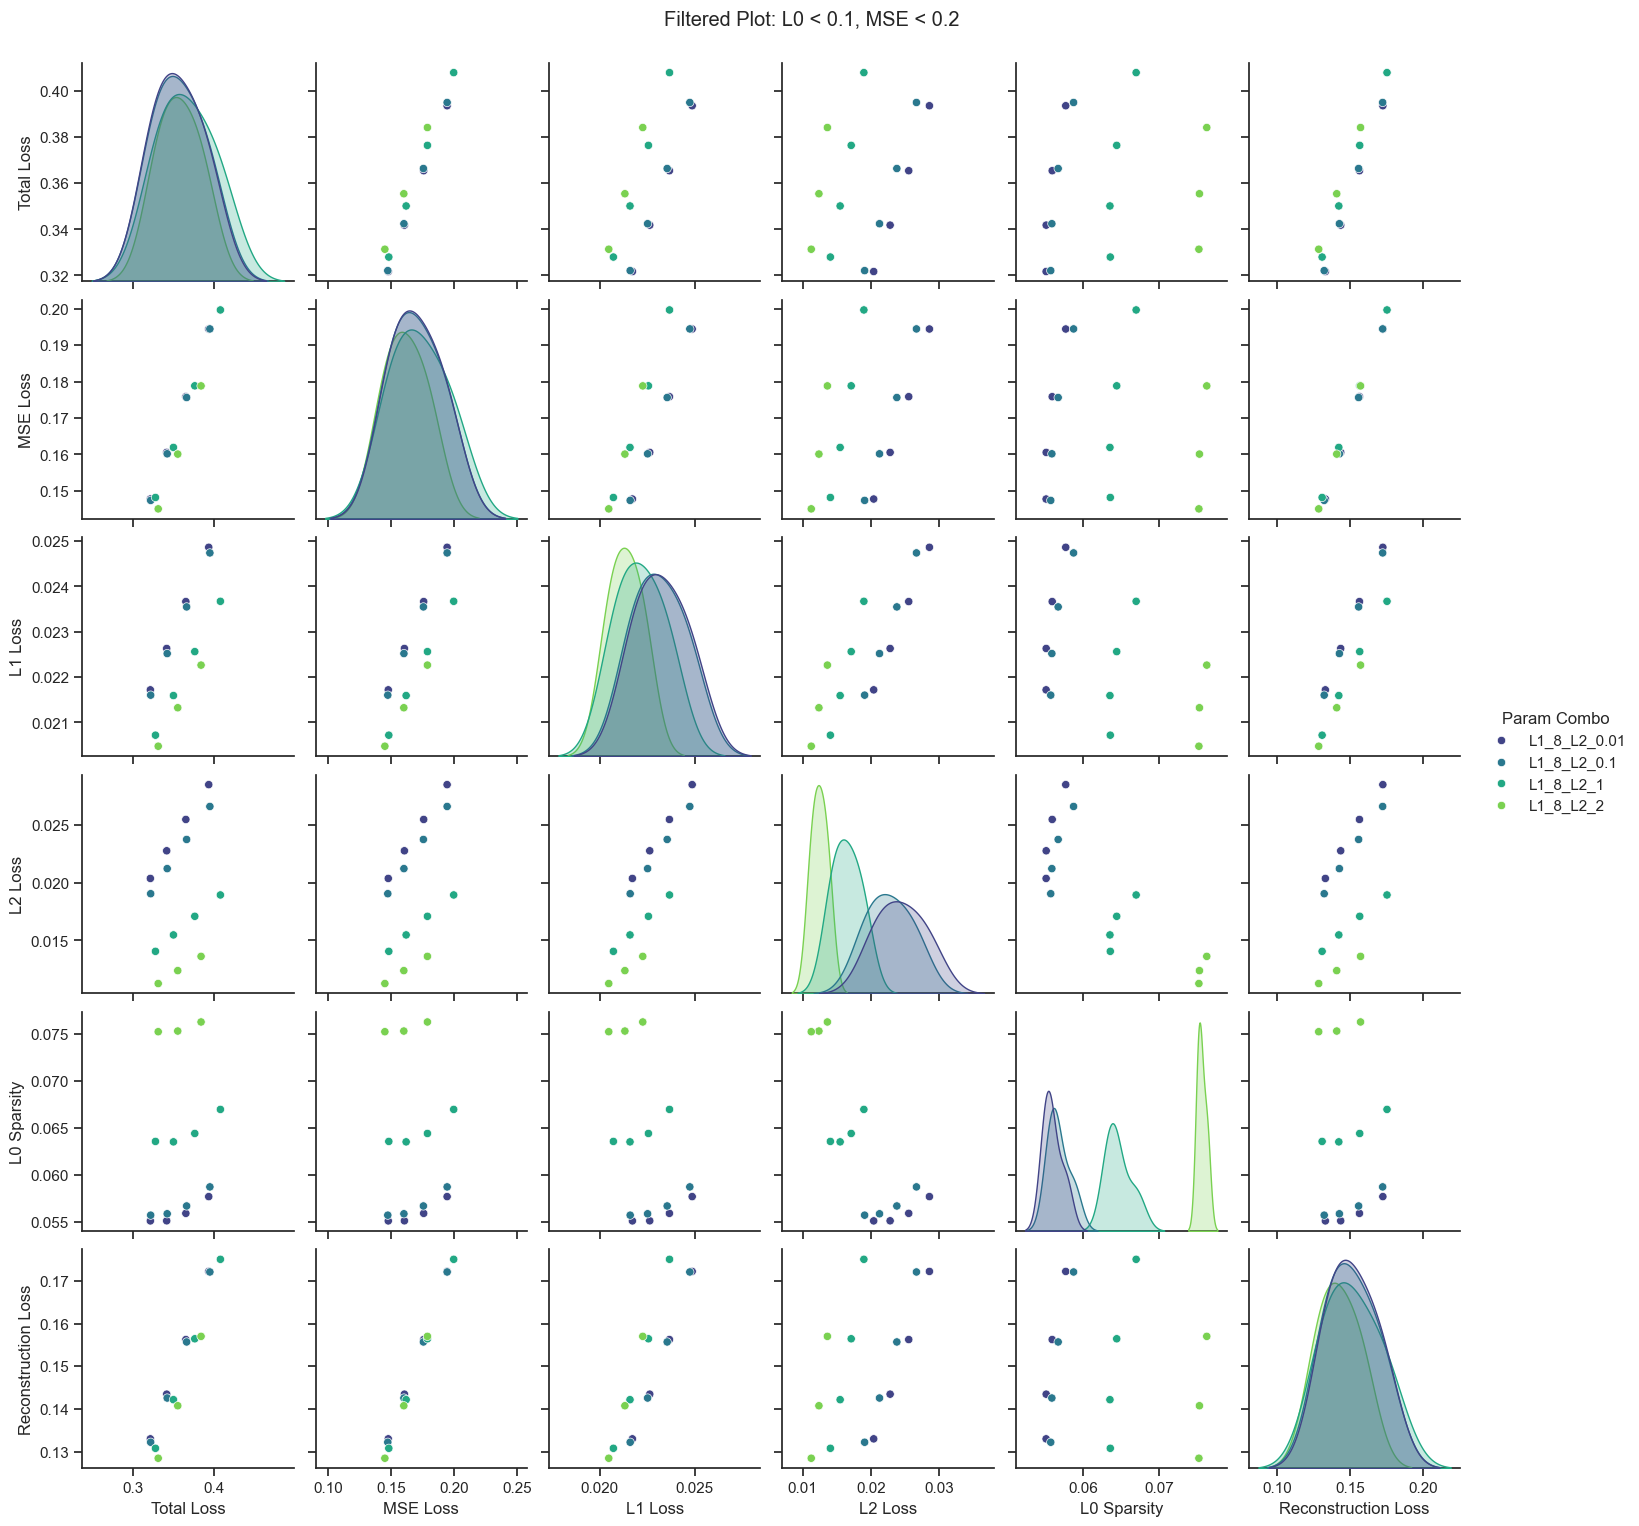

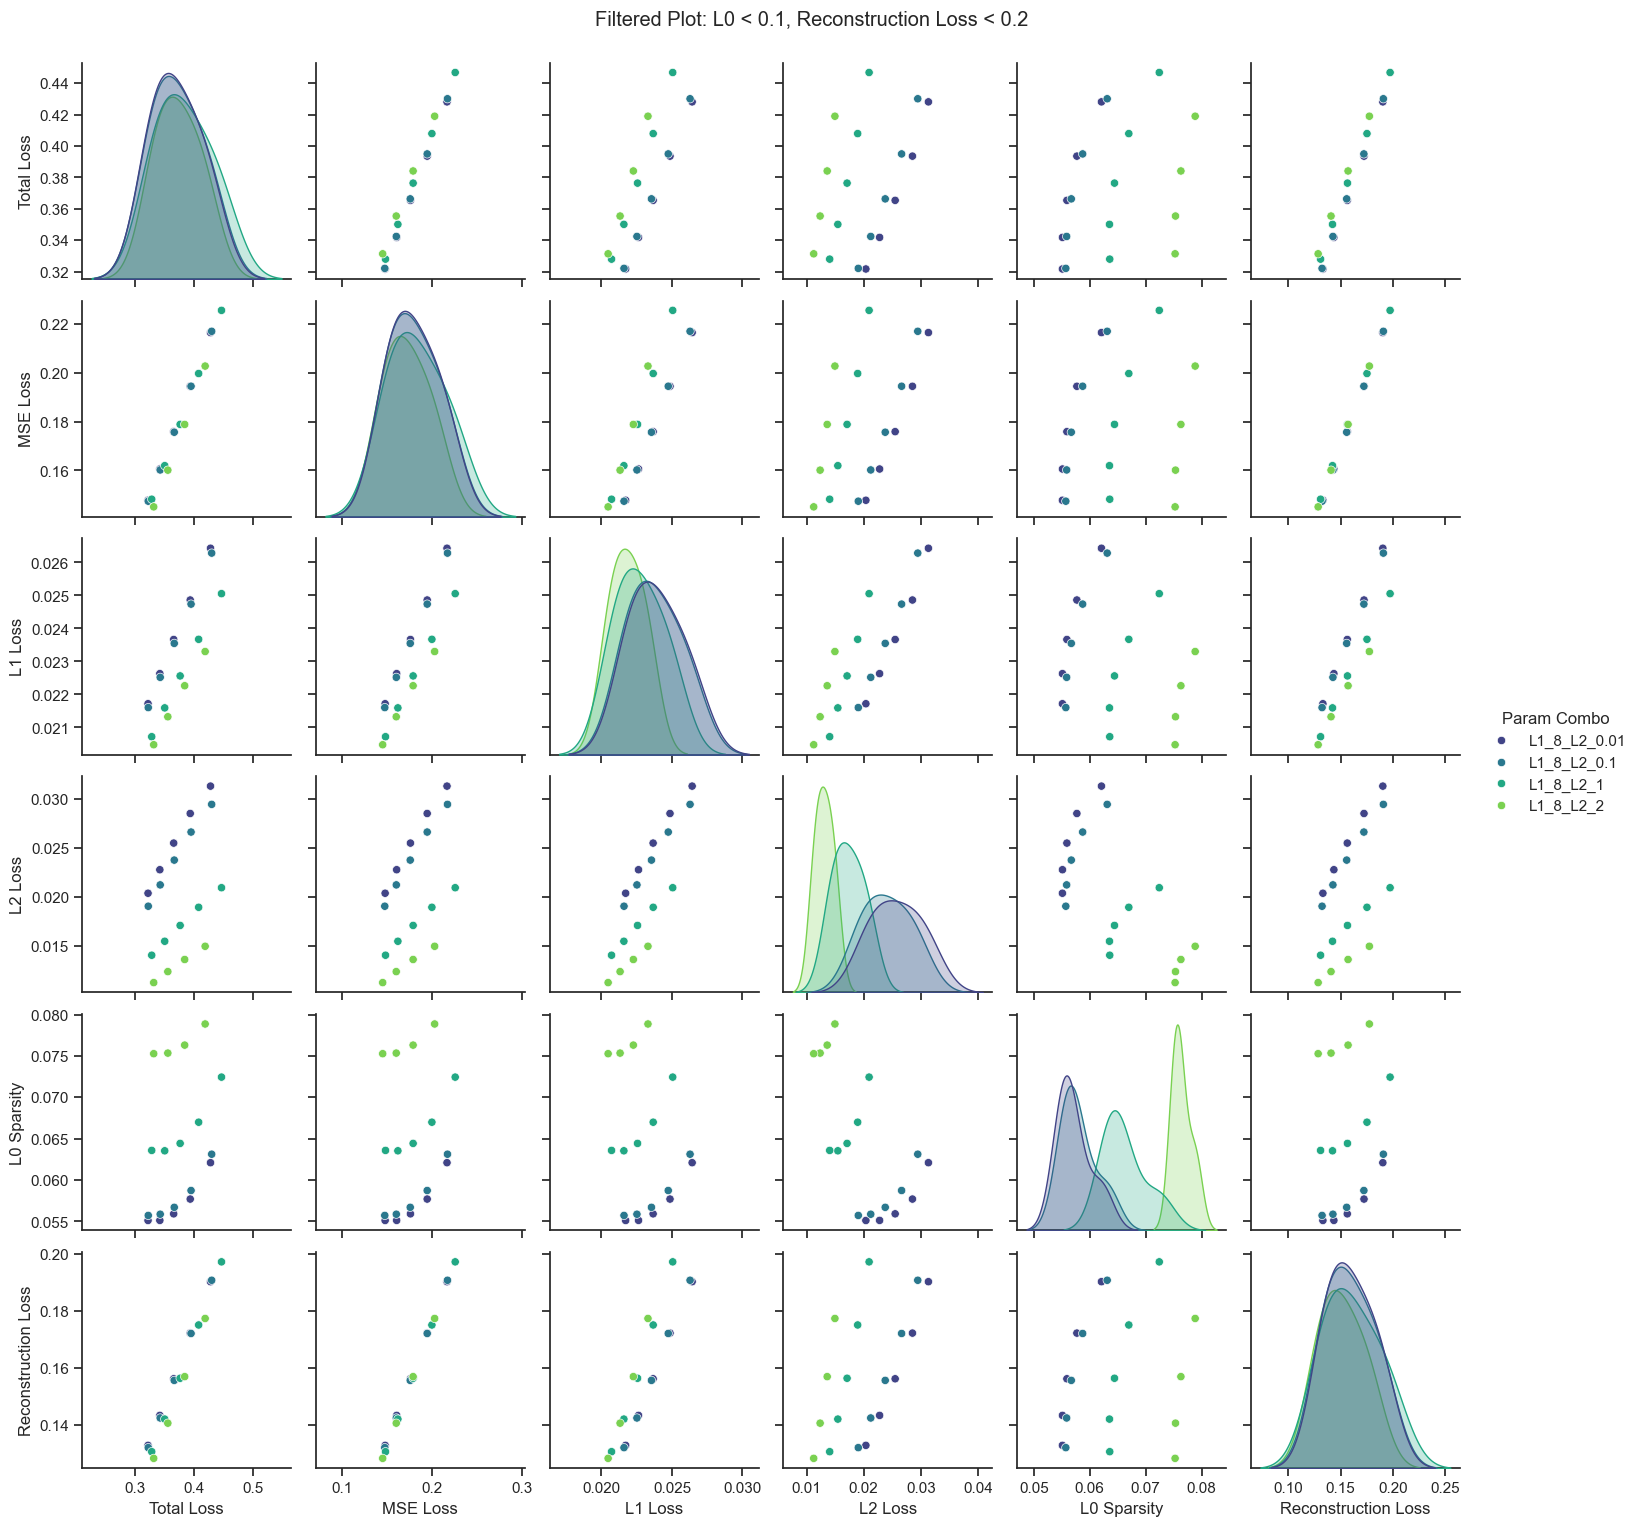

In [17]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_grid_results(GRID_out):
    """
    Creates pairplots from grid search results.
    
    GRID_out: dict produced by grid_search_SAE.
              Expected to contain a list of results in GRID_out["all_results"],
              where each result has:
                - "SAE_config": dict with SAE parameters (including 'l1_coeff' and 'l2_coeff')
                - "SAE_out": dict with "sae_training_metrics" containing lists for 
                             'loss', 'mse', 'l1', 'l2', 'l0', and 'reconstruction'
    """
    # Prepare a list to collect data rows.
    data_rows = []
    
    # Loop over each grid run result.
    for result in GRID_out["all_results"]:
        sae_config = result["SAE_config"]
        metrics = result["SAE_out"]["sae_training_metrics"]
        num_epochs = len(metrics['loss'])
        # Use l1_coeff and l2_coeff for identification.
        l1 = sae_config.get('l1_coeff', None)
        l2 = sae_config.get('l2_coeff', None)
        param_combo = f"L1_{l1}_L2_{l2}"
        for epoch in range(num_epochs):
            data_rows.append({
                'Epoch': epoch + 1,
                'Total Loss': metrics['loss'][epoch],
                'MSE Loss': metrics['mse'][epoch],
                'L1 Loss': metrics['l1'][epoch],
                'L2 Loss': metrics['l2'][epoch],
                'L0 Sparsity': metrics['l0'][epoch],
                'Reconstruction Loss': metrics['reconstruction'][epoch],
                'L1': l1,
                'L2': l2,
                'Param Combo': param_combo
            })
    
    # Create DataFrame from the collected rows.
    df_metrics = pd.DataFrame(data_rows)
    
    # Plot full pairplot.
    sns.set(style="ticks", color_codes=True)
    pair_plot_full = sns.pairplot(df_metrics, 
                                  vars=['Total Loss', 'MSE Loss', 'L1 Loss', 'L2 Loss', 'L0 Sparsity', 'Reconstruction Loss'],
                                  hue='Param Combo',
                                  diag_kind="kde", markers="o")
    pair_plot_full.fig.suptitle("Paired Plot of SAE Metrics (colored by L1 & L2)", y=1.02)
    plt.show()
    
    # Filter DataFrame: L0 Sparsity < 0.1 and MSE Loss < 0.2.
    df_filtered_mse = df_metrics[(df_metrics['L0 Sparsity'] < 0.1) & (df_metrics['MSE Loss'] < 0.2)]
    pair_plot_filtered_mse = sns.pairplot(df_filtered_mse, 
                                          vars=['Total Loss', 'MSE Loss', 'L1 Loss', 'L2 Loss', 'L0 Sparsity', 'Reconstruction Loss'],
                                          hue='Param Combo',
                                          palette="viridis",
                                          diag_kind="kde", markers="o")
    pair_plot_filtered_mse.fig.suptitle("Filtered Plot: L0 < 0.1, MSE < 0.2", y=1.02)
    plt.show()
    
    # Filter DataFrame: L0 Sparsity < 0.1 and Reconstruction Loss < 0.2.
    df_filtered_recon = df_metrics[(df_metrics['L0 Sparsity'] < 0.1) & (df_metrics['Reconstruction Loss'] < 0.2)]
    pair_plot_filtered_recon = sns.pairplot(df_filtered_recon, 
                                            vars=['Total Loss', 'MSE Loss', 'L1 Loss', 'L2 Loss', 'L0 Sparsity', 'Reconstruction Loss'],
                                            hue='Param Combo',
                                            palette="viridis",
                                            diag_kind="kde", markers="o")
    pair_plot_filtered_recon.fig.suptitle("Filtered Plot: L0 < 0.1, Reconstruction Loss < 0.2", y=1.02)
    plt.show()

# Example call:
plot_grid_results(GRID_out)


# keep